# 05 -- P-Median Capacity Allocation MILP and Accessibility Evaluation

Implements the finalised outline:

- **3.3.3 Phase 3** -- a single-stage, lambda-penalised capacitated p-median MILP.
  Objective: $\min \sum_i\sum_j D_i(\alpha)\, d_{ij}\, y_{ij} + \lambda \sum_j s_j$.
  Constraints C1-C4 (destination-side slack $s_j$ in C1; no C5 / service-radius scenario).
- **3.3.4 Phase 4** -- Scenario Analysis (12 core $\alpha\times p$ configurations solved
  directly -- no separate smoke-test subset, no reuse branching) and a single inverse-distance
  accessibility measure $A_i(\alpha,p) = \sum_j \frac{e_j+x_j(\alpha,p)}{d_{ij}+c}$.

Every configuration is solved once, in one pass; model-validity checks (solver status, C1-C3
constraint satisfaction, non-degenerate self-assignment) are computed for all 12 runs together
and reported before the figures, not gated behind a separate pre-check phase.

Maps use a split rendering (grey/white for zero-valued LSOAs, colour scale only over the
non-zero range) rather than a single continuous colour scale -- consistent with the categorical
+ continuous treatment already used for the EDA and O2 mismatch figures.

## 0. Setup and execution controls

In [19]:
from pathlib import Path
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy.interpolate import griddata
from scipy.stats import spearmanr

try:
    from shapely import vectorized as shapely_vectorized
except ImportError:
    shapely_vectorized = None

try:
    import pulp
except ImportError as exc:
    raise ImportError(
        "PuLP is required. Install it in the active environment with: pip install pulp"
    ) from exc

BASE = Path(os.environ.get(
    "DISSERTATION_BASE",
    "/Users/alexia/Documents/CASA/Dissertation",
))
PROCESSED_DIR = BASE / "05_processed"
OUTPUT_DIR = BASE / "06_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures" / "05_p_median"
TABLES_DIR = OUTPUT_DIR / "tables" / "05_p_median"
SOLVER_LOG_DIR = OUTPUT_DIR / "solver_logs"

for directory in [PROCESSED_DIR, OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, SOLVER_LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PATHS = {
    "demand": PROCESSED_DIR / "demand_london.csv",
    "boundaries": BASE / "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp",
}
for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

# Core scenario design from the outline.
SCENARIOS = {
    "A": {"alpha": 0.0, "demand_col": "D_A"},
    "B": {"alpha": 0.1, "demand_col": "D_B"},
    "C": {"alpha": 0.3, "demand_col": "D_C"},
    "D": {"alpha": 0.5, "demand_col": "D_D"},
}
P_VALUES = [2_000, 5_000, 8_000]
REFERENCE_SCENARIO = "C"
P_REF = 5_000
U_MAX = 150
K_NEIGHBOURS = 40

# Slack penalty: lambda = factor x largest distance in the permitted sparse network (outline item 10).
SLACK_PENALTY_FACTOR = 1.05

# Accessibility distance-decay constant (outline Phase 4B, item 6).
ACCESSIBILITY_C = 100.0

# Run controls. No separate smoke-test phase -- the core grid is solved directly.
RUN_FULL_GRID = True
RUN_SENSITIVITY = True
RUN_EXTENDED_P_SENSITIVITY = True
SAVE_POSITIVE_ASSIGNMENTS = True  # needed for the y_ij-vs-d_ij scatter (section 10.6)

# Optional extended investment curve for Results/Discussion.
EXTENDED_P_VALUES = [1_000, 2_000, 3_500, 5_000, 6_500, 8_000, 10_000]
EXTENDED_P_SCENARIOS = ["A", "C"]

DEFAULT_TIME_LIMIT_SECONDS = 300
RELATIVE_GAP_TARGET = 0.02
CBC_MESSAGES = True

print("Using project base:", BASE)
print("PuLP version:", pulp.__version__)


Using project base: /Users/alexia/Documents/CASA/Dissertation
PuLP version: 3.3.2


## 1. Build the common LSOA demand/allocation table \((I=J)\)

In [2]:
def require_columns(df: pd.DataFrame, required: list[str], name: str) -> None:
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"{name}: missing required columns {missing}")


demand = pd.read_csv(PATHS["demand"])
require_columns(
    demand,
    [
        "lsoa_code", "e_i", "D_A", "D_B", "D_C", "D_D", "IMD_i",
        # "london_income_decile" not required here -- computed below directly from IMD_i,
        # whether or not the upstream demand_london.csv already includes it.
    ],
    "demand_london.csv",
)

# London-specific deprivation deciles (1 = most deprived, 10 = least deprived).
# rank(method="first") breaks ties so the 10 groups split exactly 499/500.
income_rank = demand["IMD_i"].rank(method="first", ascending=False)
demand["london_income_decile"] = pd.qcut(income_rank, 10, labels=False) + 1

decile_check = demand.groupby("london_income_decile")["IMD_i"].agg(["count", "min", "max"])
assert demand["london_income_decile"].between(1, 10).all()
assert decile_check["count"].between(499, 500).all(), "Decile groups should each hold exactly 499 or 500 LSOAs."

boundaries = gpd.read_file(PATHS["boundaries"])
if boundaries.crs is None:
    boundaries = boundaries.set_crs(epsg=27700)
elif boundaries.crs.to_epsg() != 27700:
    boundaries = boundaries.to_crs(epsg=27700)

lsoa_geometry = (
    boundaries.loc[boundaries["LSOA21CD"].isin(demand["lsoa_code"])]
    .rename(columns={"LSOA21CD": "lsoa_code"})
    [["lsoa_code", "geometry"]]
    .copy()
)
lsoa_geometry["centroid"] = lsoa_geometry.geometry.centroid
lsoa_geometry["cx"] = lsoa_geometry["centroid"].x
lsoa_geometry["cy"] = lsoa_geometry["centroid"].y

lsoa_master = (
    demand.merge(
        lsoa_geometry[["lsoa_code", "cx", "cy"]],
        on="lsoa_code",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("lsoa_code")
    .reset_index(drop=True)
)

if len(lsoa_master) != len(demand):
    raise ValueError("Some demand LSOAs did not match the boundary file.")
if lsoa_master["lsoa_code"].duplicated().any():
    raise ValueError("lsoa_master is not one row per LSOA.")
if lsoa_master[["D_A", "D_B", "D_C", "D_D", "e_i", "cx", "cy"]].isna().any().any():
    raise ValueError("Missing values found in required model inputs.")
if not lsoa_master["london_income_decile"].between(1, 10).all():
    raise ValueError("london_income_decile must contain values from 1 to 10.")

n = len(lsoa_master)
coords = lsoa_master[["cx", "cy"]].to_numpy(dtype=float)
D0 = lsoa_master["D_A"].to_numpy(dtype=float)
e_existing = lsoa_master["e_i"].to_numpy(dtype=float)
K0 = D0.sum() / (e_existing.sum() + P_REF)

print(f"Demand nodes |I|: {n:,}")
print(f"Candidate allocation nodes |J|: {n:,}")
print(f"Existing on-street locations: {e_existing.sum():,.0f}")
print(f"K0: {K0:.6f}")


Demand nodes |I|: 4,994
Candidate allocation nodes |J|: 4,994
Existing on-street locations: 21,364
K0: 13.167604


## 2. Sparse assignment network for the MILP ($k$-NN pruning, solver only)

In [3]:
def build_assignment_arcs(
    coordinates: np.ndarray,
    k: int,
) -> tuple[list[list[int]], dict[tuple[int, int], float]]:
    # Return sparse candidate lists and Euclidean distances for permitted MILP arcs.
    #
    # This is the k-nearest-neighbour pruning step from outline 3.3.3: a computational
    # sparsification for the solver, not a policy distance rule. It has no bearing on the
    # accessibility measure in Phase 4B, which uses the full Greater London network instead
    # (see section 3 below).
    n_nodes = len(coordinates)
    if k < 1:
        raise ValueError("k must be at least 1.")

    tree = cKDTree(coordinates)
    distances, neighbours = tree.query(coordinates, k=min(k, n_nodes))
    distances = np.atleast_2d(distances)
    neighbours = np.atleast_2d(neighbours)

    candidate_lists: list[list[int]] = []
    distance_lookup: dict[tuple[int, int], float] = {}

    for i in range(n_nodes):
        row: list[int] = []
        for distance, j in zip(np.atleast_1d(distances[i]), np.atleast_1d(neighbours[i])):
            j = int(j)
            distance = float(distance)
            row.append(j)
            distance_lookup[(i, j)] = distance

        # Keep the self-link. Whether it dominates is checked after solving.
        if i not in row:
            row.append(i)
            distance_lookup[(i, i)] = 0.0

        candidate_lists.append(sorted(set(row)))

    return candidate_lists, distance_lookup


BASE_CANDIDATES, BASE_DISTANCES = build_assignment_arcs(coords, k=K_NEIGHBOURS)

n_arcs = sum(len(row) for row in BASE_CANDIDATES)
print(f"Permitted assignment arcs: {n_arcs:,}")
print(f"Mean candidates per demand node: {n_arcs/n:.1f}")
print(f"Maximum retained distance: {max(BASE_DISTANCES.values()):,.1f} m")
print("All self-links retained:", all(i in BASE_CANDIDATES[i] for i in range(n)))


Permitted assignment arcs: 199,760
Mean candidates per demand node: 40.0
Maximum retained distance: 7,522.9 m
All self-links retained: True


## 3. Full Greater London distance matrix for accessibility evaluation

Built once and reused for every $A_i(\alpha,p)$ computation in Phase 4B. Deliberately **not**
restricted to the $k=40$ sparse candidate set above -- accessibility is evaluated against every
LSOA's full existing-plus-additional provision, regardless of whether the solver was permitted
to assign demand there.

In [4]:
FULL_DISTANCE_MATRIX = cdist(coords, coords)

print(f"Full distance matrix: {FULL_DISTANCE_MATRIX.shape}, "
      f"{FULL_DISTANCE_MATRIX.nbytes / 1e6:,.1f} MB")
print(f"Matrix diagonal (self-distance) max: {FULL_DISTANCE_MATRIX.diagonal().max():.6f} "
      "(should be 0)")


def compute_accessibility(x_j: np.ndarray, c: float = ACCESSIBILITY_C) -> np.ndarray:
    # A_i(alpha,p) = sum_j (e_j + x_j) / (d_ij + c), over the full LSOA network.
    supply_j = e_existing + np.asarray(x_j, dtype=float)
    return (supply_j[None, :] / (FULL_DISTANCE_MATRIX + c)).sum(axis=1)


print("compute_accessibility defined.")


Full distance matrix: (4994, 4994), 199.5 MB
Matrix diagonal (self-distance) max: 0.000000 (should be 0)
compute_accessibility defined.


## 4. MILP formulation and CBC solution function

$$\min \sum_i\sum_j D_i(\alpha)\, d_{ij}\, y_{ij} + \lambda \sum_j s_j$$

subject to C1 ($\sum_i D_i^\alpha y_{ij} \le K(e_j+x_j)+s_j,\ s_j\ge0$), C2
($\sum_j y_{ij}=1$), C3 ($\sum_j x_j = p$), C4 (domains). $\lambda = 1.05 \times$ the longest
distance actually present in the permitted sparse network.

In [5]:
def parse_cbc_log(log_path: Path, status: str) -> dict[str, float | None]:
    # Extract a best bound and reported gap from a CBC log when available.
    result = {"best_bound": None, "reported_gap": 0.0 if status == "Optimal" else None}
    if not log_path.exists():
        return result

    text = log_path.read_text(errors="ignore")
    bound_matches = re.findall(r"Lower bound:\s*([-+0-9.eE]+)", text)
    gap_matches = re.findall(r"Gap:\s*([-+0-9.eE]+)", text)
    if bound_matches:
        result["best_bound"] = float(bound_matches[-1])
    if gap_matches:
        result["reported_gap"] = float(gap_matches[-1])
    return result


def solve_capacity_allocation(
    scenario_label: str,
    p: int,
    K: float,
    U_j: int = U_MAX,
    k: int = K_NEIGHBOURS,
    time_limit_seconds: int = DEFAULT_TIME_LIMIT_SECONDS,
    relative_gap_target: float = RELATIVE_GAP_TARGET,
    slack_penalty_factor: float = SLACK_PENALTY_FACTOR,
    save_assignments: bool = False,
) -> dict:
    # Solve the sparse, capacitated p-median MILP (C1-C4) with a lambda-penalised
    # destination-side slack. No service-radius option (C5 removed from the finalised outline).
    if scenario_label not in SCENARIOS:
        raise KeyError(f"Unknown scenario label: {scenario_label}")
    if p < 0 or p > n * U_j:
        raise ValueError("p is incompatible with the local upper bounds.")
    if slack_penalty_factor <= 1:
        raise ValueError("slack_penalty_factor should be greater than 1.")

    demand_col = SCENARIOS[scenario_label]["demand_col"]
    D_alpha = lsoa_master[demand_col].to_numpy(dtype=float)

    if k == K_NEIGHBOURS:
        candidate_lists = BASE_CANDIDATES
        distance_lookup = BASE_DISTANCES
    else:
        candidate_lists, distance_lookup = build_assignment_arcs(coords, k=k)

    permitted_arcs = [
        (i, j) for i, candidates_i in enumerate(candidate_lists) for j in candidates_i
    ]
    max_arc_distance = max(distance_lookup.values())
    slack_penalty = slack_penalty_factor * max(max_arc_distance, 1.0)

    model_name = f"pmedian_{scenario_label}_p{p}_K{K:.6f}_U{U_j}_k{k}"
    model = pulp.LpProblem(model_name, pulp.LpMinimize)

    x = {j: pulp.LpVariable(f"x_{j}", lowBound=0, upBound=U_j, cat="Integer") for j in range(n)}
    y = {(i, j): pulp.LpVariable(f"y_{i}_{j}", lowBound=0, upBound=1, cat="Continuous")
         for i, j in permitted_arcs}
    s = {j: pulp.LpVariable(f"s_{j}", lowBound=0, cat="Continuous") for j in range(n)}

    distance_term = pulp.lpSum(
        D_alpha[i] * distance_lookup[(i, j)] * y[(i, j)] for i, j in permitted_arcs
    )
    slack_term = slack_penalty * pulp.lpSum(s[j] for j in range(n))
    model += distance_term + slack_term

    for i, candidates_i in enumerate(candidate_lists):
        model += (pulp.lpSum(y[(i, j)] for j in candidates_i) == 1, f"assignment_{i}")  # C2

    incoming_by_j: dict[int, list[int]] = {j: [] for j in range(n)}
    for i, j in permitted_arcs:
        incoming_by_j[j].append(i)

    for j in range(n):
        model += (
            pulp.lpSum(D_alpha[i] * y[(i, j)] for i in incoming_by_j[j])
            <= K * (e_existing[j] + x[j]) + s[j],
            f"capacity_{j}",
        )  # C1

    model += (pulp.lpSum(x[j] for j in range(n)) == p, "fixed_budget")  # C3

    log_path = SOLVER_LOG_DIR / f"{model_name}.log"
    solver = pulp.PULP_CBC_CMD(
        msg=int(CBC_MESSAGES), timeLimit=time_limit_seconds,
        gapRel=relative_gap_target, logPath=str(log_path),
    )

    start_time = time.perf_counter()
    status_code = model.solve(solver)
    runtime_seconds = time.perf_counter() - start_time
    status = pulp.LpStatus.get(status_code, str(status_code))

    x_values = np.array([float(x[j].value() or 0.0) for j in range(n)])
    s_values = np.array([float(s[j].value() or 0.0) for j in range(n)])

    dbar_i = np.zeros(n, dtype=float)
    own_share_i = np.zeros(n, dtype=float)
    assigned_demand_j = np.zeros(n, dtype=float)
    positive_assignment_rows: list[dict] = []
    n_positive_assignments = 0

    for i, j in permitted_arcs:
        y_value = float(y[(i, j)].value() or 0.0)
        if y_value > 1e-9:
            n_positive_assignments += 1
            dbar_i[i] += distance_lookup[(i, j)] * y_value
            assigned_demand_j[j] += D_alpha[i] * y_value
            if i == j:
                own_share_i[i] += y_value
            if save_assignments:
                positive_assignment_rows.append({
                    "scenario": scenario_label, "alpha": SCENARIOS[scenario_label]["alpha"],
                    "p": p, "demand_lsoa": lsoa_master.iloc[i]["lsoa_code"],
                    "allocation_lsoa": lsoa_master.iloc[j]["lsoa_code"],
                    "distance_m": distance_lookup[(i, j)], "y_ij": y_value,
                    "assigned_demand": D_alpha[i] * y_value,
                })

    total_demand = float(D_alpha.sum())
    total_slack = float(s_values.sum())
    distance_objective = float(np.sum(D_alpha * dbar_i))
    slack_penalty_component = float(slack_penalty * total_slack)
    penalised_objective = distance_objective + slack_penalty_component

    assignment_sum_error = max(
        abs(sum(float(y[(i, j)].value() or 0.0) for j in candidate_lists[i]) - 1.0)
        for i in range(n)
    )
    budget_error = abs(x_values.sum() - p)
    capacity_violation = float(np.max(
        assigned_demand_j - (K * (e_existing + x_values) + s_values)
    ))

    log_diagnostics = parse_cbc_log(log_path, status)

    result = {
        "scenario": scenario_label, "alpha": SCENARIOS[scenario_label]["alpha"],
        "demand_col": demand_col, "p": p, "K": K, "U_j": U_j, "k": k,
        "status": status, "runtime_seconds": runtime_seconds,
        "relative_gap_target": relative_gap_target,
        "reported_gap": log_diagnostics["reported_gap"], "best_bound": log_diagnostics["best_bound"],
        "n_assignment_arcs": len(permitted_arcs), "n_positive_assignments": n_positive_assignments,
        "slack_penalty_factor": slack_penalty_factor, "slack_penalty": slack_penalty,
        "distance_objective": distance_objective,
        "slack_penalty_component": slack_penalty_component,
        "penalised_objective": penalised_objective,
        "total_demand": total_demand, "total_slack": total_slack,
        "slack_share_of_demand": total_slack / total_demand if total_demand > 0 else np.nan,
        "x_j": x_values, "s_j": s_values, "dbar_i": dbar_i, "own_share_i": own_share_i,
        "assigned_demand_j": assigned_demand_j,
        "assignment_sum_error": assignment_sum_error, "budget_error": budget_error,
        "maximum_capacity_violation": capacity_violation,
        "assignment_rows": pd.DataFrame(positive_assignment_rows),
    }

    if assignment_sum_error > 1e-5:
        warnings.warn(f"Maximum assignment-sum error is {assignment_sum_error:.3e}.")
    if budget_error > 1e-5:
        warnings.warn(f"Investment-budget error is {budget_error:.3e}.")
    if capacity_violation > 1e-5:
        warnings.warn(f"Maximum capacity violation is {capacity_violation:.3e}.")

    return result


print("solve_capacity_allocation defined.")


solve_capacity_allocation defined.


## 5. Accessibility evaluation and run-summary functions

$$\bar A(\alpha,p) = \frac{\sum_i D_i^{(0)} A_i(\alpha,p)}{\sum_i D_i^{(0)}}$$

`evaluate_run` returns one scalar summary row per $(\alpha,p)$ configuration; $A_i$ and
$\Delta A_i$ arrays are computed on demand elsewhere via `compute_accessibility`.

In [6]:
def weighted_mean(values: np.ndarray, weights: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    if not valid.any() or weights[valid].sum() <= 0:
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def evaluate_run(result: dict, baseline_A_bar_by_p: dict[int, float] | None = None) -> dict:
    x_values = np.asarray(result["x_j"], dtype=float)
    A_i = compute_accessibility(x_values)
    A_bar = weighted_mean(A_i, D0)

    A_bar_pct_change = np.nan
    if baseline_A_bar_by_p is not None and result["p"] in baseline_A_bar_by_p:
        baseline_A_bar = baseline_A_bar_by_p[result["p"]]
        if np.isfinite(baseline_A_bar) and baseline_A_bar > 1e-12:
            A_bar_pct_change = 100 * (A_bar - baseline_A_bar) / baseline_A_bar

    own_assignment_share = weighted_mean(result["own_share_i"], D0)

    return {
        "scenario": result["scenario"], "alpha": result["alpha"], "p": result["p"],
        "K": result["K"], "U_j": result["U_j"], "k": result["k"],
        "status": result["status"], "runtime_seconds": result["runtime_seconds"],
        "reported_gap": result["reported_gap"],
        "distance_objective": result["distance_objective"],
        "penalised_objective": result["penalised_objective"],
        "A_bar": A_bar,
        "A_bar_pct_change_vs_alpha0": A_bar_pct_change,
        "absolute_mean_distance_m": weighted_mean(result["dbar_i"], D0),
        "D0_weighted_own_assignment_share": own_assignment_share,
        "total_slack": result["total_slack"],
        "slack_share_of_demand": result["slack_share_of_demand"],
        "n_lsoas_with_x_j_gt_0": int((x_values > 1e-9).sum()),
        "maximum_x_j": float(x_values.max()),
        "assignment_sum_error": result["assignment_sum_error"],
        "budget_error": result["budget_error"],
        "maximum_capacity_violation": result["maximum_capacity_violation"],
    }


def print_run_summary(result: dict) -> None:
    print(
        f"status={result['status']}; runtime={result['runtime_seconds']:.1f}s; "
        f"distance objective={result['distance_objective']:,.3f}; "
        f"total slack={result['total_slack']:,.3f}; "
        f"slack share={result['slack_share_of_demand']:.2%}"
    )


print("evaluate_run and print_run_summary defined.")


evaluate_run and print_run_summary defined.


## 6. Core $\alpha\times p$ scenario grid, solved directly

All 12 configurations are solved in one pass -- no smoke-test subset, no reuse branching.
Model-validity checks (solver status, C1-C3 satisfaction, non-degenerate self-assignment) are
computed for every configuration and reported together immediately afterwards.

In [7]:
core_results: dict[tuple[str, int], dict] = {}
core_rows: list[dict] = []
validity_rows: list[dict] = []

if RUN_FULL_GRID:
    for scenario_label in SCENARIOS:
        for p in P_VALUES:
            print(f"\nSolving Scenario {scenario_label}, p={p:,}")
            result = solve_capacity_allocation(
                scenario_label=scenario_label, p=p, K=K0, U_j=U_MAX, k=K_NEIGHBOURS,
                time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS,
                save_assignments=SAVE_POSITIVE_ASSIGNMENTS,
            )
            print_run_summary(result)
            core_results[(scenario_label, p)] = result

    baseline_A_bar_by_p = {
        p: weighted_mean(compute_accessibility(core_results[("A", p)]["x_j"]), D0)
        for p in P_VALUES
    }

    for result in core_results.values():
        row = evaluate_run(result, baseline_A_bar_by_p)
        row.update({
            "solver_status_acceptable": result["status"] in {"Optimal", "Not Solved"},
            "assignment_constraints_ok": result["assignment_sum_error"] <= 1e-5,
            "budget_constraint_ok": result["budget_error"] <= 1e-5,
            "capacity_constraints_ok": result["maximum_capacity_violation"] <= 1e-5,
            "own_assignment_not_dominant": row["D0_weighted_own_assignment_share"] < 0.99,
        })
        core_rows.append(row)

    core_summary = pd.DataFrame(core_rows).sort_values(["p", "alpha"]).reset_index(drop=True)

    validity_columns = [
        "solver_status_acceptable", "assignment_constraints_ok", "budget_constraint_ok",
        "capacity_constraints_ok", "own_assignment_not_dominant",
    ]
    model_validity_passed = bool(core_summary[validity_columns].all(axis=None))

    zero_baseline_p = [p for p, value in baseline_A_bar_by_p.items() if not np.isfinite(value) or value <= 1e-12]
    if zero_baseline_p:
        warnings.warn(f"A_bar percentage change is undefined at p={zero_baseline_p}.")

    print("\n=== Core accessibility summary ===")
    summary_columns = [
        "scenario", "alpha", "p", "status", "A_bar", "A_bar_pct_change_vs_alpha0",
        "slack_share_of_demand", "D0_weighted_own_assignment_share",
        "n_lsoas_with_x_j_gt_0", "runtime_seconds",
    ]
    print(core_summary[summary_columns].to_string(index=False, float_format=lambda v: f"{v:,.6f}"))

    print("\n=== Model-validity checks ===")
    print(core_summary[["scenario", "p", *validity_columns]].to_string(index=False))
    print("\nAll model-validity checks passed:", model_validity_passed)
    if not model_validity_passed:
        warnings.warn(
            "At least one configuration failed a mathematical validity check. "
            "Inspect the table above and the solver logs before treating results as final."
        )

    print("\n=== x_j response to alpha (relative to Scenario A at the same p) ===")
    for p in P_VALUES:
        baseline_x = core_results[("A", p)]["x_j"]
        for scenario_label in ["B", "C", "D"]:
            x_l1 = float(np.abs(core_results[(scenario_label, p)]["x_j"] - baseline_x).sum())
            print(f"p={p:,}, {scenario_label} vs A: L1 change in x_j = {x_l1:,.1f}")
else:
    core_summary = pd.DataFrame()
    model_validity_passed = False
    print("RUN_FULL_GRID=False: the core grid was not run.")



Solving Scenario A, p=2,000


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/coin_api.py:212: UserWarning: `logPath` argument replaces `msg=1`. The output will be redirected to the log file.
  warnings.warn(


status=Optimal; runtime=13.2s; distance objective=92,102,399.067; total slack=151,460.978; slack share=43.63%

Solving Scenario A, p=5,000
status=Optimal; runtime=30.1s; distance objective=92,102,399.067; total slack=111,958.166; slack share=32.25%

Solving Scenario A, p=8,000
status=Optimal; runtime=58.6s; distance objective=92,102,399.067; total slack=72,455.355; slack share=20.87%

Solving Scenario B, p=2,000
status=Optimal; runtime=13.6s; distance objective=93,556,755.771; total slack=157,476.328; slack share=44.27%

Solving Scenario B, p=5,000
status=Optimal; runtime=38.3s; distance objective=93,556,755.771; total slack=117,973.517; slack share=33.16%

Solving Scenario B, p=8,000
status=Optimal; runtime=58.5s; distance objective=93,556,755.771; total slack=78,470.705; slack share=22.06%

Solving Scenario C, p=2,000
status=Optimal; runtime=13.5s; distance objective=96,552,395.193; total slack=169,590.462; slack share=45.47%

Solving Scenario C, p=5,000
status=Optimal; runtime=27.5s

## 7. Sensitivity analysis ($K$, $U_j$, $k$)

In [20]:
sensitivity_rows: list[dict] = []

if RUN_SENSITIVITY:
    sensitivity_specs: list[dict] = []

    for label, K_value in [("0.5K0", 0.5 * K0), ("K0", K0), ("2K0", 2 * K0)]:
        sensitivity_specs.append({"test": "K", "level": label, "K": K_value, "U_j": U_MAX, "k": K_NEIGHBOURS})

    for U_value in [50, 150, 300]:
        sensitivity_specs.append({"test": "U_j", "level": str(U_value), "K": K0, "U_j": U_value, "k": K_NEIGHBOURS})

    for k_value in [30, 40, 50]:
        sensitivity_specs.append({"test": "k", "level": str(k_value), "K": K0, "U_j": U_MAX, "k": k_value})

    for spec in sensitivity_specs:
        print(f"\nSensitivity: {spec['test']}={spec['level']}")
        result = solve_capacity_allocation(
            scenario_label=REFERENCE_SCENARIO, p=P_REF, K=spec["K"], U_j=spec["U_j"], k=spec["k"],
            time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS, save_assignments=False,
        )
        print_run_summary(result)
        row = evaluate_run(result)
        row.update({"sensitivity_test": spec["test"], "sensitivity_level": spec["level"]})
        sensitivity_rows.append(row)

    sensitivity_summary = pd.DataFrame(sensitivity_rows)
else:
    sensitivity_summary = pd.DataFrame()
    print("RUN_SENSITIVITY=False: parameter sensitivity models were not run.")

extended_p_results: dict[tuple[str, int], dict] = {}
extended_p_rows: list[dict] = []

if RUN_EXTENDED_P_SENSITIVITY:
    for scenario_label in EXTENDED_P_SCENARIOS:
        for p in EXTENDED_P_VALUES:
            key = (scenario_label, p)
            print(f"\nExtended p sensitivity: Scenario {scenario_label}, p={p:,}")
            result = solve_capacity_allocation(
                scenario_label=scenario_label, p=p, K=K0, U_j=U_MAX, k=K_NEIGHBOURS,
                time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS, save_assignments=False,
            )
            print_run_summary(result)
            extended_p_results[key] = result
            extended_p_rows.append(evaluate_run(result))

    extended_p_summary = pd.DataFrame(extended_p_rows).sort_values(["scenario", "p"]).reset_index(drop=True)
else:
    extended_p_summary = pd.DataFrame()
    print("RUN_EXTENDED_P_SENSITIVITY=False: extended investment curve was not run.")



Sensitivity: K=0.5K0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/coin_api.py:212: UserWarning: `logPath` argument replaces `msg=1`. The output will be redirected to the log file.
  warnings.warn(


status=Optimal; runtime=14.0s; distance objective=63,914,088.209; total slack=213,566.032; slack share=57.26%

Sensitivity: K=K0
status=Optimal; runtime=27.8s; distance objective=96,552,395.193; total slack=130,087.650; slack share=34.88%

Sensitivity: K=2K0
status=Optimal; runtime=161.4s; distance objective=116,576,785.479; total slack=16,520.448; slack share=4.43%

Sensitivity: U_j=50
status=Optimal; runtime=28.7s; distance objective=96,552,395.193; total slack=130,087.650; slack share=34.88%

Sensitivity: U_j=150
status=Optimal; runtime=27.0s; distance objective=96,552,395.193; total slack=130,087.650; slack share=34.88%

Sensitivity: U_j=300
status=Optimal; runtime=26.2s; distance objective=96,552,395.193; total slack=130,087.650; slack share=34.88%

Sensitivity: k=30
status=Optimal; runtime=20.7s; distance objective=72,355,521.081; total slack=135,470.147; slack share=36.32%

Sensitivity: k=40
status=Optimal; runtime=26.2s; distance objective=96,552,395.193; total slack=130,087.65

## 8. Save model outputs

In [9]:
if core_results:
    lsoa_results = lsoa_master[[
        "lsoa_code", "e_i", "D_A", "D_B", "D_C", "D_D", "IMD_i", "london_income_decile",
    ]].copy()

    for (scenario_label, p), result in sorted(core_results.items()):
        suffix = f"{scenario_label}_p{p}"
        lsoa_results[f"x_j_{suffix}"] = result["x_j"]
        lsoa_results[f"s_j_{suffix}"] = result["s_j"]
        lsoa_results[f"A_i_{suffix}"] = compute_accessibility(result["x_j"])

        if SAVE_POSITIVE_ASSIGNMENTS and not result["assignment_rows"].empty:
            assignment_path = PROCESSED_DIR / f"assignments_{suffix}.csv.gz"
            result["assignment_rows"].to_csv(assignment_path, index=False, compression="gzip")
            print("Saved:", assignment_path)

    lsoa_results_path = PROCESSED_DIR / "p_median_lsoa_results.csv"
    lsoa_results.to_csv(lsoa_results_path, index=False)
    print("Saved:", lsoa_results_path)

if not core_summary.empty:
    core_path = TABLES_DIR / "core_grid_accessibility.csv"
    core_summary.to_csv(core_path, index=False)
    print("Saved:", core_path)

if not sensitivity_summary.empty:
    sensitivity_path = TABLES_DIR / "sensitivity_summary.csv"
    sensitivity_summary.to_csv(sensitivity_path, index=False)
    print("Saved:", sensitivity_path)

if not extended_p_summary.empty:
    extended_p_path = TABLES_DIR / "extended_p_sensitivity.csv"
    extended_p_summary.to_csv(extended_p_path, index=False)
    print("Saved:", extended_p_path)


Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_A_p2000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_A_p5000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_A_p8000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_B_p2000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_B_p5000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_B_p8000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_C_p2000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_C_p5000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_C_p8000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_D_p2000.csv.gz
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/assignments_D_p5000.csv.gz
Saved: /Users/alexia/

# 9. Result tables and figures

In [27]:
def save_current_figure(filename: str) -> None:
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


def plot_metric_by_alpha(summary: pd.DataFrame, metric: str, ylabel: str, title: str, filename: str) -> None:
    plt.figure(figsize=(9, 6))
    for p in sorted(summary["p"].unique()):
        subset = summary.loc[summary["p"].eq(p)].sort_values("alpha")
        plt.plot(subset["alpha"], subset[metric], marker="o", label=f"p={p:,}")
    plt.xlabel(r"Income-deprivation weight $\alpha$")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    save_current_figure(filename)


def plot_split_choropleth(
    plot_data: gpd.GeoDataFrame, value_col: str, ax, title: str,
    cmap: str = "OrRd", zero_color: str = "#d9d9d9", legend_label: str = "",
    diverging: bool = False, zero_tolerance: float = 1e-9,
    zero_label: str = "Zero / no change",
) -> None:
    # Grey/white base layer for zero-valued LSOAs; colour scale stretched only over the
    # non-zero range -- the same categorical + continuous treatment used for the EDA D panel
    # and the O2 mismatch-classification map, applied here to x_j / delta_x / delta_A_i.
    zero_mask = plot_data[value_col].abs() <= zero_tolerance
    changed = plot_data.loc[~zero_mask]
    unchanged = plot_data.loc[zero_mask]

    unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)

    if not changed.empty:
        if diverging:
            bound = float(changed[value_col].abs().max())
            vmin, vmax = -bound, bound
        else:
            vmin, vmax = float(changed[value_col].min()), float(changed[value_col].max())
        changed.plot(
            column=value_col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
            edgecolor="white", linewidth=0.05, legend=True,
            legend_kwds={"label": legend_label, "shrink": 0.65},
        )

    handles = [Patch(facecolor=zero_color, edgecolor="none", label=zero_label)]
    ax.legend(handles=handles, loc="lower left", fontsize=8, frameon=True)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")


from shapely.geometry import Point
from shapely.prepared import prep


def plot_smooth_heatmap(
    values, ax, title, cmap="OrRd", grid_resolution=700,  # 400 -> 700，边缘更贴合
    legend_label="", diverging=False, show_lsoa_outlines=True,
):
    minx, miny, maxx, maxy = lsoa_geometry.total_bounds
    xi = np.linspace(minx, maxx, grid_resolution)
    yi = np.linspace(miny, maxy, grid_resolution)
    grid_x, grid_y = np.meshgrid(xi, yi)

    grid_z = griddata(coords, values, (grid_x, grid_y), method="cubic")

    london_outline = (
        lsoa_geometry.union_all() if hasattr(lsoa_geometry, "union_all")
        else lsoa_geometry.unary_union
    )
    prepared_outline = prep(london_outline)
    flat_points = [Point(x, y) for x, y in zip(grid_x.ravel(), grid_y.ravel())]
    inside = np.array([prepared_outline.contains(p) for p in flat_points]).reshape(grid_x.shape)
    grid_z = np.ma.array(grid_z, mask=(~inside) | np.isnan(grid_z))

    if diverging:
        bound = float(np.nanmax(np.abs(values)))
        vmin, vmax = -bound, bound
    else:
        vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))

    im = ax.imshow(grid_z, extent=(xi.min(), xi.max(), yi.min(), yi.max()),
                    origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,
                    interpolation="nearest")  # 关键改动：关掉抗锯齿，不再往外渗色
    plt.colorbar(im, ax=ax, shrink=0.65, label=legend_label)

    if show_lsoa_outlines:
        lsoa_geometry.boundary.plot(ax=ax, color="grey", linewidth=0.1, alpha=0.35)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")
    ax.set_aspect("equal")



def base_map_frame() -> gpd.GeoDataFrame:
    return (
        lsoa_geometry[["lsoa_code", "geometry"]]
        .merge(lsoa_master[["lsoa_code"]], on="lsoa_code", how="inner", validate="one_to_one")
        .sort_values("lsoa_code")
        .reset_index(drop=True)
    )


## 9.1 Core accessibility figures ($\bar A(\alpha,p)$)

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_A_bar_accessibility.png


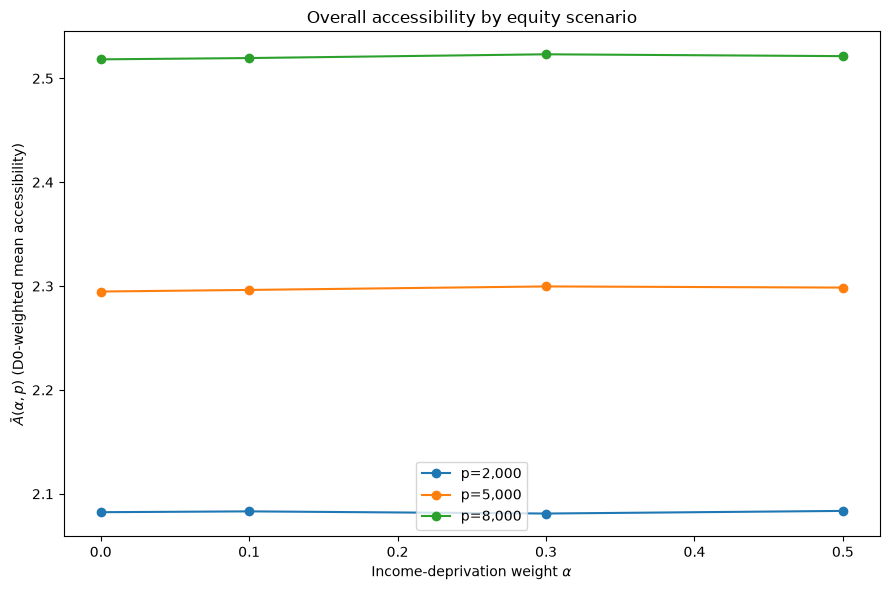

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_A_bar_pct_change.png


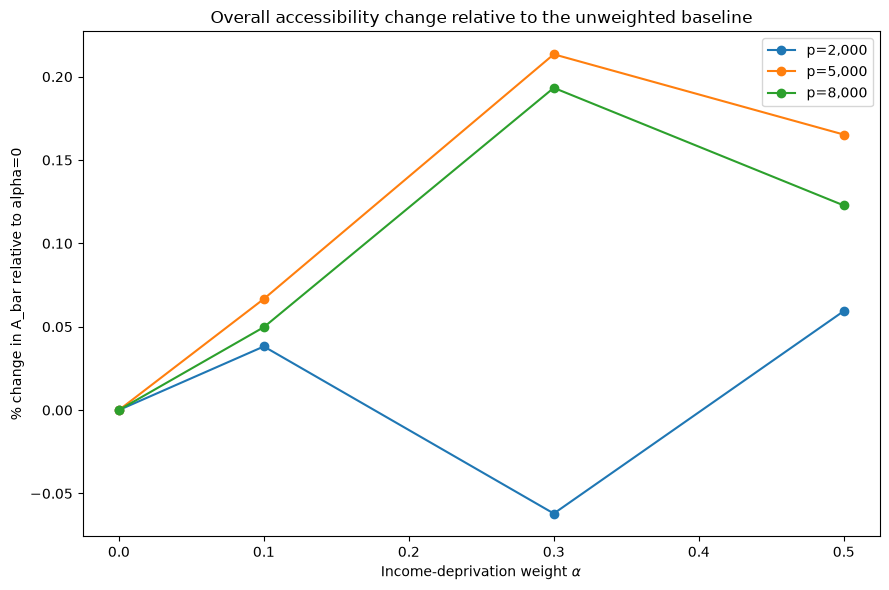

In [11]:
if not core_summary.empty:
    plot_metric_by_alpha(
        core_summary, "A_bar", r"$\bar A(\alpha,p)$ (D0-weighted mean accessibility)",
        "Overall accessibility by equity scenario", "fig_A_bar_accessibility.png",
    )
    plot_metric_by_alpha(
        core_summary, "A_bar_pct_change_vs_alpha0", "% change in A_bar relative to alpha=0",
        "Overall accessibility change relative to the unweighted baseline",
        "fig_A_bar_pct_change.png",
    )
else:
    print("Accessibility figures skipped: run the full core grid first.")


## 9.2 Model-behaviour diagnostics

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_slack_share.png


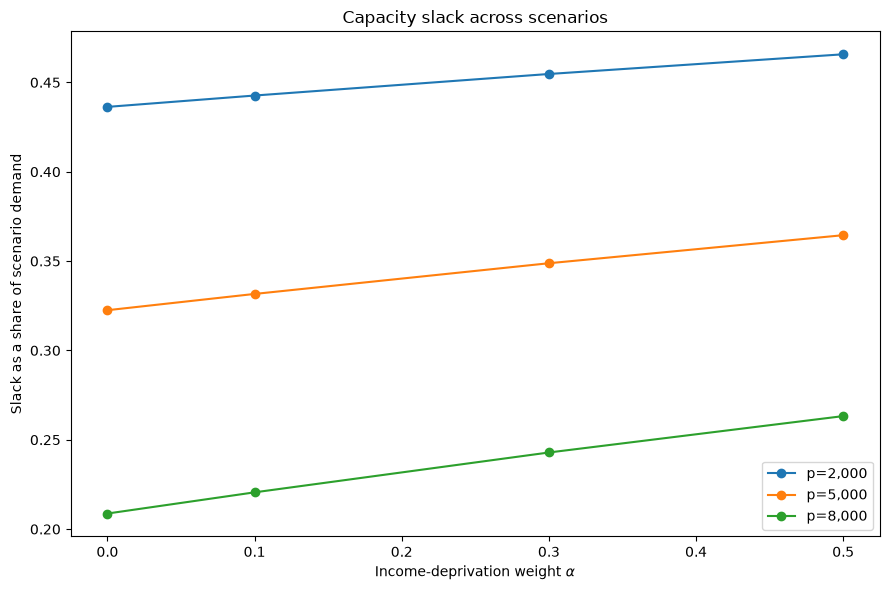

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_own_assignment_share.png


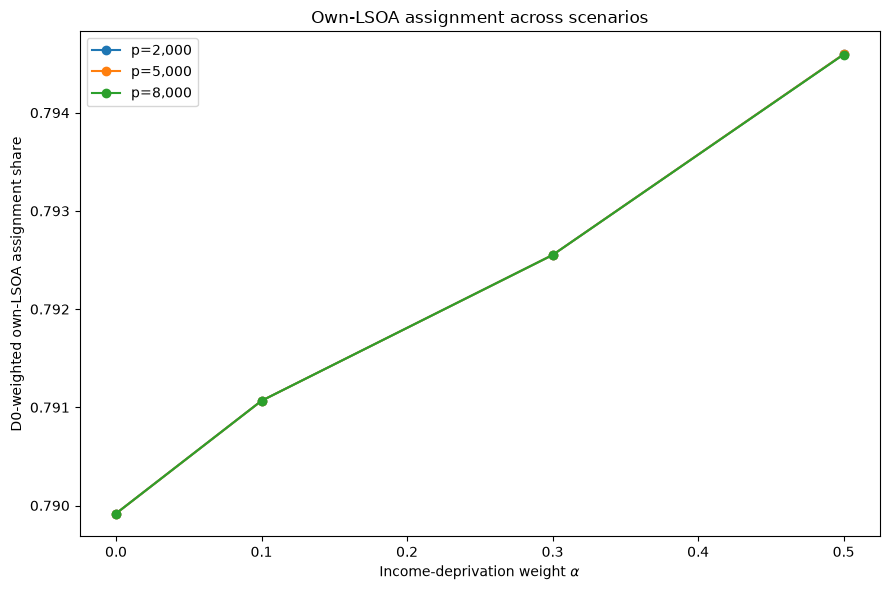

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_absolute_mean_distance.png


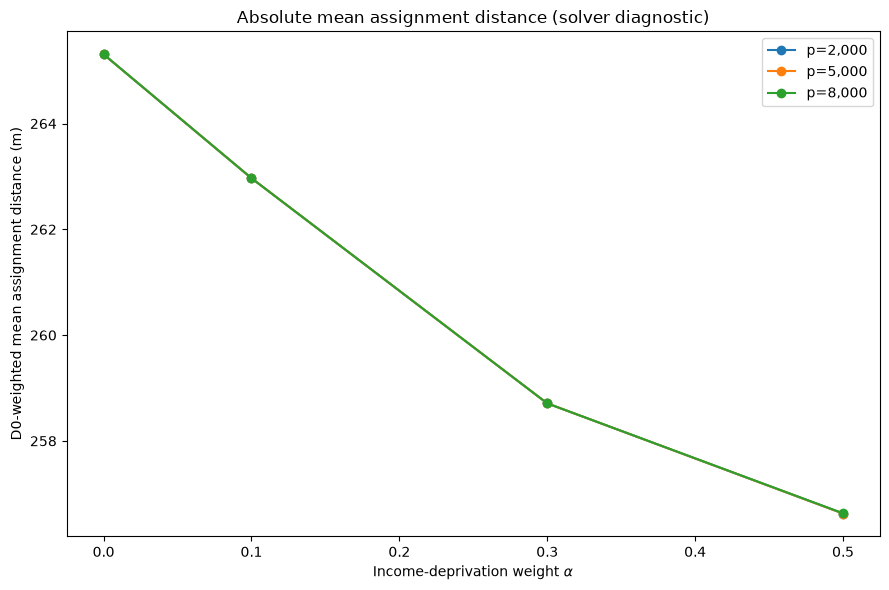

In [12]:
if not core_summary.empty:
    plot_metric_by_alpha(
        core_summary, "slack_share_of_demand", "Slack as a share of scenario demand",
        "Capacity slack across scenarios", "fig_slack_share.png",
    )
    plot_metric_by_alpha(
        core_summary, "D0_weighted_own_assignment_share", "D0-weighted own-LSOA assignment share",
        "Own-LSOA assignment across scenarios", "fig_own_assignment_share.png",
    )
    plot_metric_by_alpha(
        core_summary, "absolute_mean_distance_m", "D0-weighted mean assignment distance (m)",
        "Absolute mean assignment distance (solver diagnostic)", "fig_absolute_mean_distance.png",
    )
else:
    print("Diagnostic figures skipped: run the full core grid first.")


## 9.3 Deprivation-decile profiles of $\Delta A_i(\alpha,p)$

scenario    A         B         C         D
decile                                     
1         0.0  0.001011 -0.018951 -0.008520
2         0.0  0.001938 -0.002024 -0.000189
3         0.0  0.001803  0.005436  0.003266
4         0.0 -0.000693  0.000495 -0.001476
5         0.0  0.002321  0.000761 -0.000691
6         0.0 -0.001422  0.002278  0.002251
7         0.0 -0.001153  0.001178 -0.001700
8         0.0  0.002434  0.007155  0.002894
9         0.0  0.003568  0.017070  0.014468
10        0.0  0.004386  0.021152  0.018052
Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_decile_delta_accessibility_p5000.png


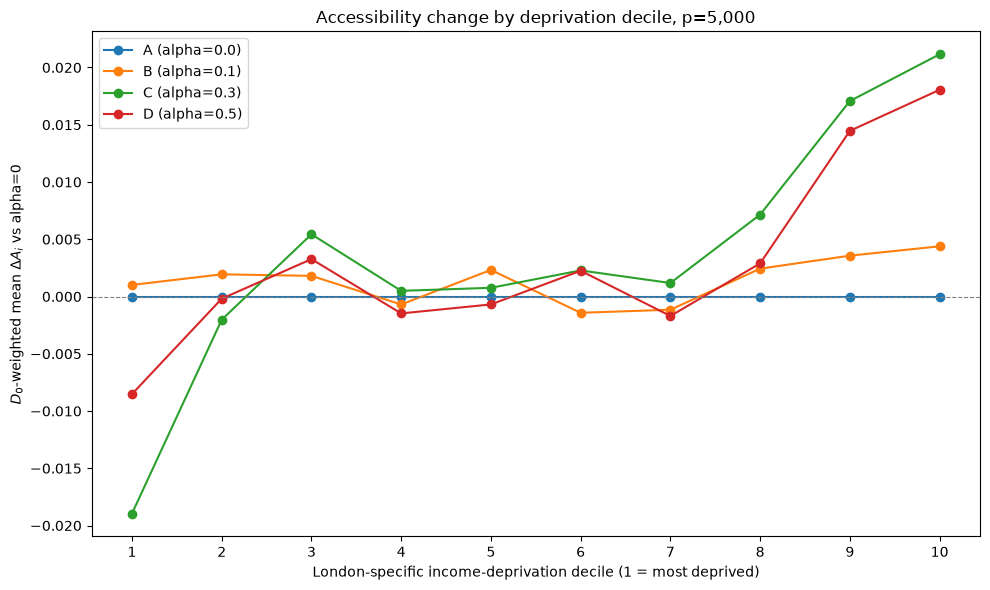

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_decile_capacity_profiles_p5000.png


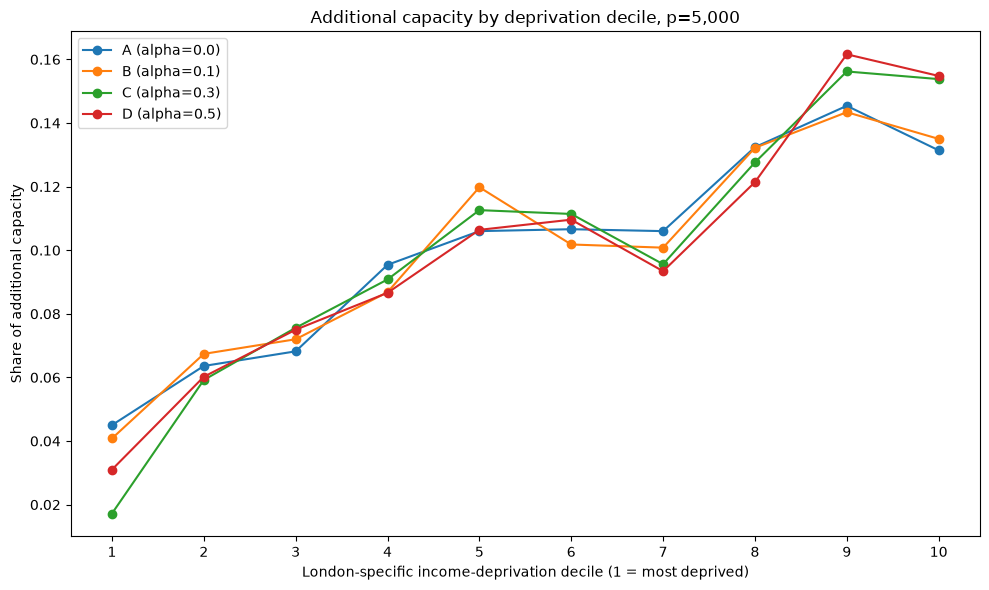

In [13]:
def build_decile_profiles(results: dict[tuple[str, int], dict], p: int) -> pd.DataFrame:
    rows: list[dict] = []
    deciles = lsoa_master["london_income_decile"].to_numpy(dtype=int)

    baseline_key = ("A", p)
    if baseline_key not in results:
        return pd.DataFrame()
    baseline_A_i = compute_accessibility(results[baseline_key]["x_j"])

    for scenario_label in SCENARIOS:
        key = (scenario_label, p)
        if key not in results:
            continue
        result = results[key]
        A_i = compute_accessibility(result["x_j"])
        delta_A_i = A_i - baseline_A_i
        x_values = np.asarray(result["x_j"], dtype=float)

        for decile in range(1, 11):
            mask = deciles == decile
            rows.append({
                "scenario": scenario_label, "alpha": SCENARIOS[scenario_label]["alpha"], "p": p,
                "decile": decile,
                "mean_delta_A_i": weighted_mean(delta_A_i[mask], D0[mask]),
                "capacity_units": float(x_values[mask].sum()),
                "capacity_share": float(x_values[mask].sum() / p),
                "baseline_demand_share": float(D0[mask].sum() / D0.sum()),
            })
    return pd.DataFrame(rows)


if core_results and all((scenario, P_REF) in core_results for scenario in SCENARIOS):
    decile_profiles = build_decile_profiles(core_results, P_REF)
    decile_profiles.to_csv(TABLES_DIR / "decile_profiles_p5000.csv", index=False)
    print(decile_profiles.pivot(index="decile", columns="scenario", values="mean_delta_A_i").to_string())

    plt.figure(figsize=(10, 6))
    for scenario_label in SCENARIOS:
        subset = decile_profiles.loc[decile_profiles["scenario"].eq(scenario_label)]
        plt.plot(subset["decile"], subset["mean_delta_A_i"], marker="o",
                  label=f"{scenario_label} (alpha={SCENARIOS[scenario_label]['alpha']})")
    plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    plt.xlabel("London-specific income-deprivation decile (1 = most deprived)")
    plt.ylabel(r"$D_0$-weighted mean $\Delta A_i$ vs alpha=0")
    plt.title(f"Accessibility change by deprivation decile, p={P_REF:,}")
    plt.xticks(range(1, 11))
    plt.legend()
    save_current_figure("fig_decile_delta_accessibility_p5000.png")

    plt.figure(figsize=(10, 6))
    for scenario_label in SCENARIOS:
        subset = decile_profiles.loc[decile_profiles["scenario"].eq(scenario_label)]
        plt.plot(subset["decile"], subset["capacity_share"], marker="o",
                  label=f"{scenario_label} (alpha={SCENARIOS[scenario_label]['alpha']})")
    plt.xlabel("London-specific income-deprivation decile (1 = most deprived)")
    plt.ylabel("Share of additional capacity")
    plt.title(f"Additional capacity by deprivation decile, p={P_REF:,}")
    plt.xticks(range(1, 11))
    plt.legend()
    save_current_figure("fig_decile_capacity_profiles_p5000.png")
else:
    decile_profiles = pd.DataFrame()
    print("Decile profiles skipped: all four reference-p scenarios are required.")


## 9.4 Allocation and accessibility-change maps (split choropleth)

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_A_p5000.png


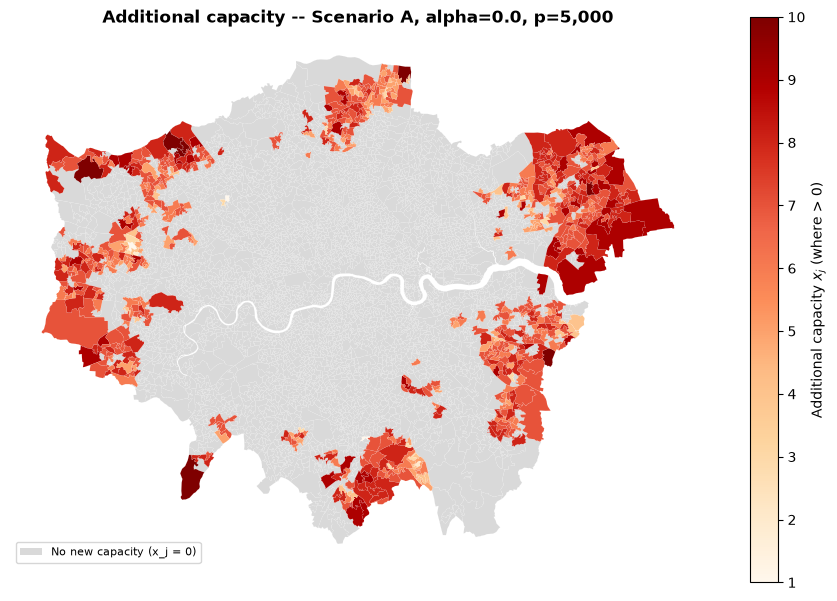

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_B_p5000.png


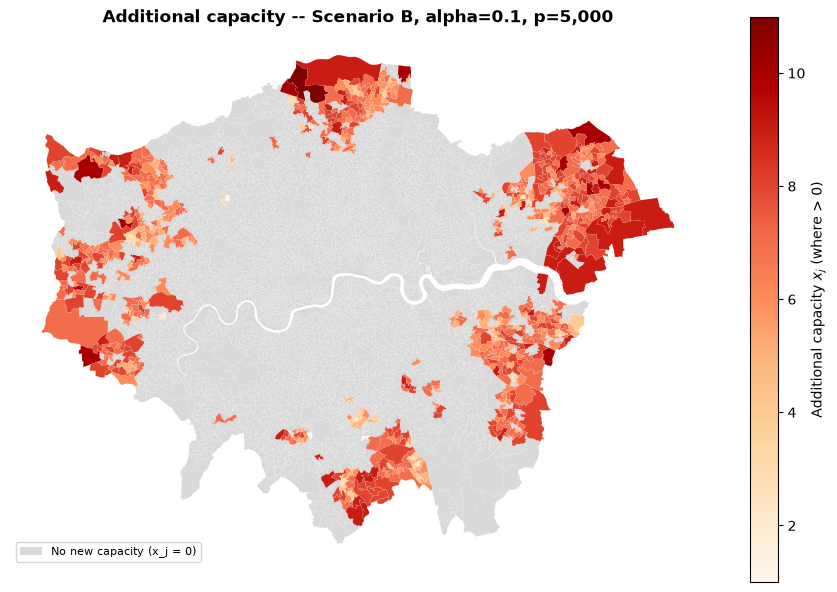

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_C_p5000.png


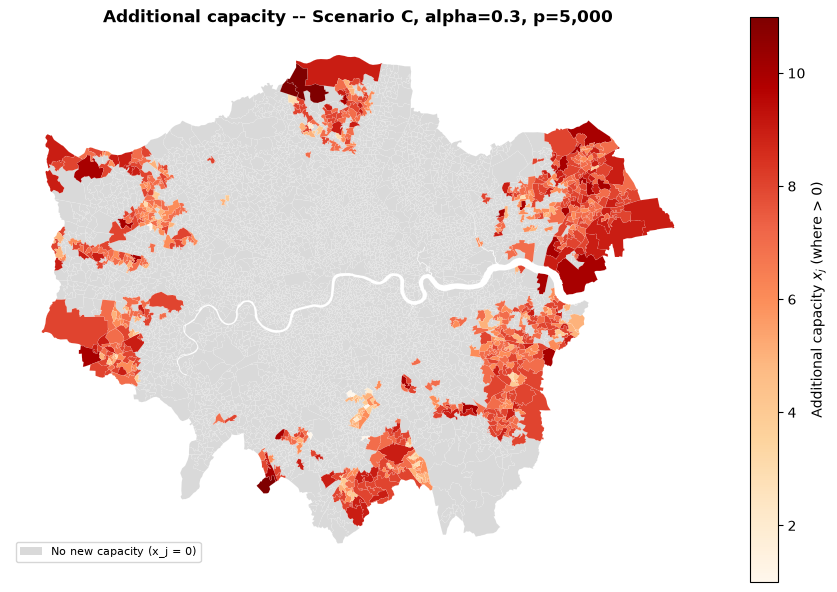

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_D_p5000.png


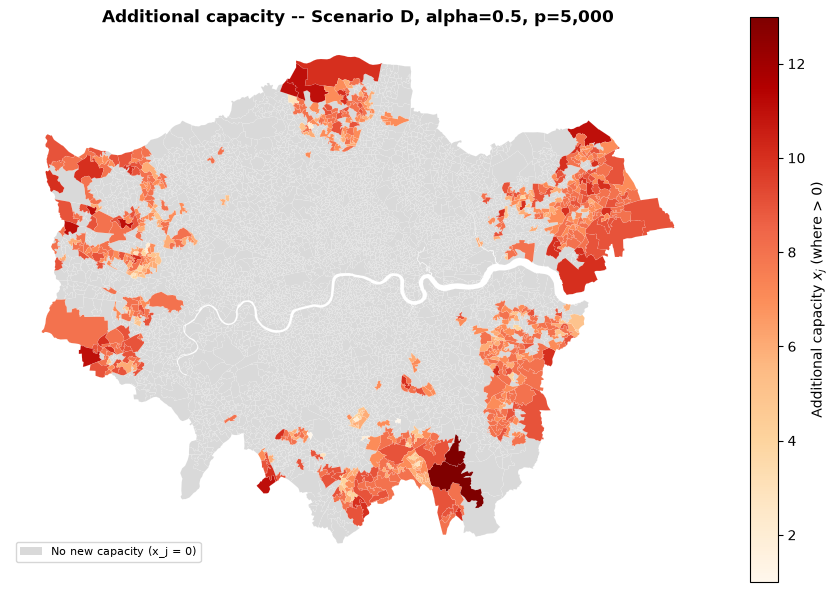

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_x_B_minus_A_p5000.png


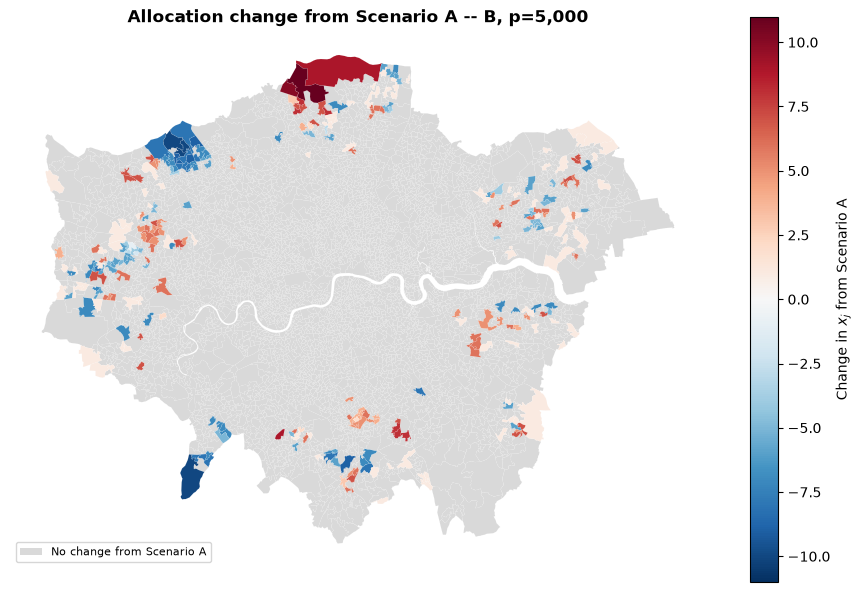

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_x_C_minus_A_p5000.png


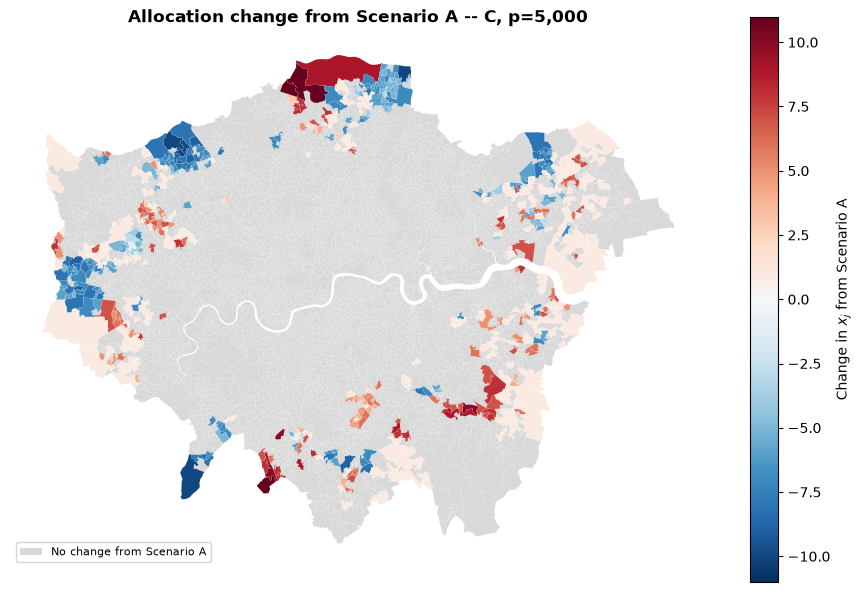

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_x_D_minus_A_p5000.png


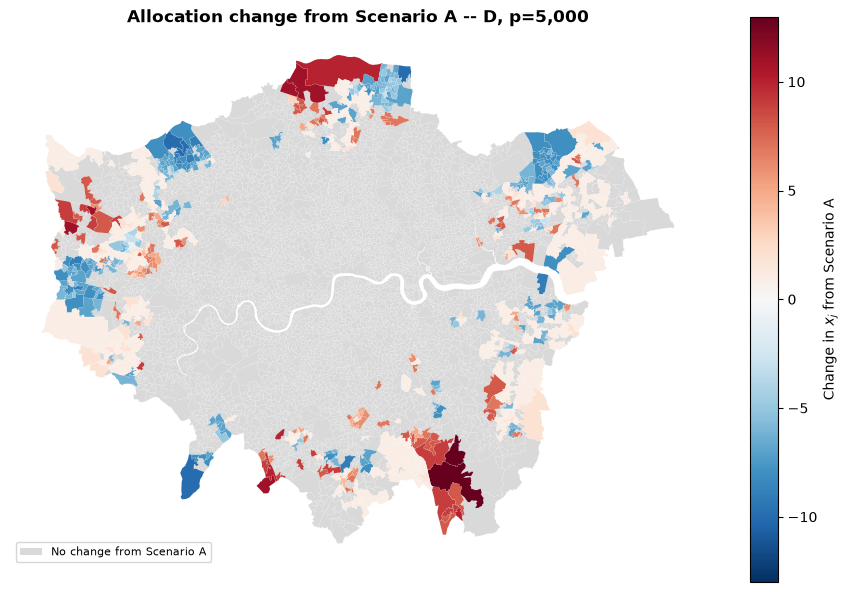

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_12322/3121556203.py:34: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_A_B_minus_A_p5000.png


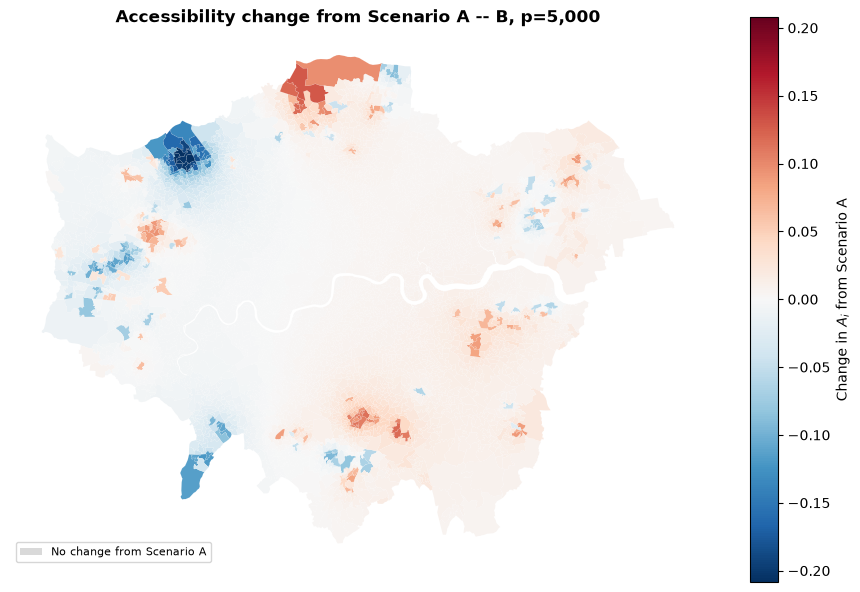

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_12322/3121556203.py:34: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_A_C_minus_A_p5000.png


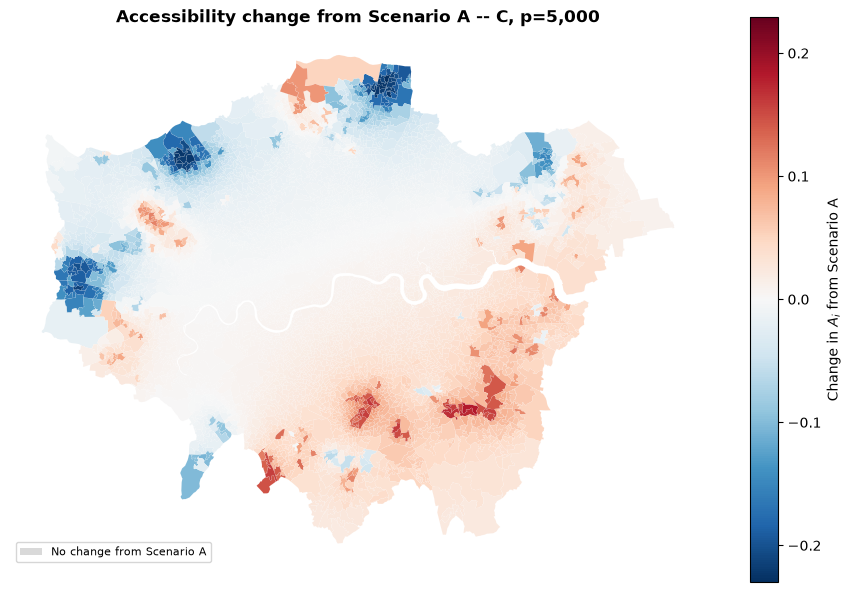

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_12322/3121556203.py:34: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_A_D_minus_A_p5000.png


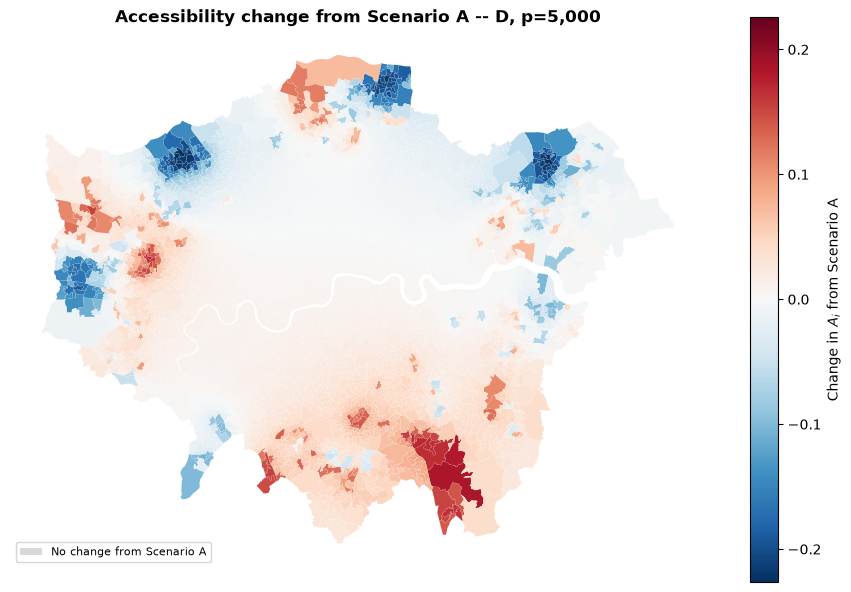

In [14]:
if core_results and all((scenario, P_REF) in core_results for scenario in SCENARIOS):
    map_base = base_map_frame()

    for scenario_label in SCENARIOS:
        plot_data = map_base.copy()
        plot_data["x_j"] = core_results[(scenario_label, P_REF)]["x_j"]
        fig, ax = plt.subplots(figsize=(9, 9))
        plot_split_choropleth(
            plot_data, "x_j", ax,
            f"Additional capacity -- Scenario {scenario_label}, "
            f"alpha={SCENARIOS[scenario_label]['alpha']}, p={P_REF:,}",
            cmap="OrRd", legend_label=r"Additional capacity $x_j$ (where > 0)",
            zero_label="No new capacity (x_j = 0)",
        )
        save_current_figure(f"map_x_{scenario_label}_p{P_REF}.png")

    baseline_x = core_results[("A", P_REF)]["x_j"]
    for scenario_label in ["B", "C", "D"]:
        plot_data = map_base.copy()
        plot_data["delta_x"] = core_results[(scenario_label, P_REF)]["x_j"] - baseline_x
        fig, ax = plt.subplots(figsize=(9, 9))
        plot_split_choropleth(
            plot_data, "delta_x", ax,
            f"Allocation change from Scenario A -- {scenario_label}, p={P_REF:,}",
            cmap="RdBu_r", diverging=True,
            legend_label=r"Change in $x_j$ from Scenario A",
            zero_label="No change from Scenario A",
        )
        save_current_figure(f"map_delta_x_{scenario_label}_minus_A_p{P_REF}.png")

    baseline_A_i = compute_accessibility(baseline_x)
    for scenario_label in ["B", "C", "D"]:
        plot_data = map_base.copy()
        plot_data["delta_A_i"] = compute_accessibility(core_results[(scenario_label, P_REF)]["x_j"]) - baseline_A_i
        fig, ax = plt.subplots(figsize=(9, 9))
        plot_split_choropleth(
            plot_data, "delta_A_i", ax,
            f"Accessibility change from Scenario A -- {scenario_label}, p={P_REF:,}",
            cmap="RdBu_r", diverging=True,
            legend_label=r"Change in $A_i$ from Scenario A",
            zero_label="No change from Scenario A",
        )
        save_current_figure(f"map_delta_A_{scenario_label}_minus_A_p{P_REF}.png")
else:
    print("Maps skipped: all four reference-p scenarios are required.")


## 9.5 Smooth accessibility heatmaps ($A_i$, $\Delta A_i$)

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/heatmap_A_i_A_p5000.png


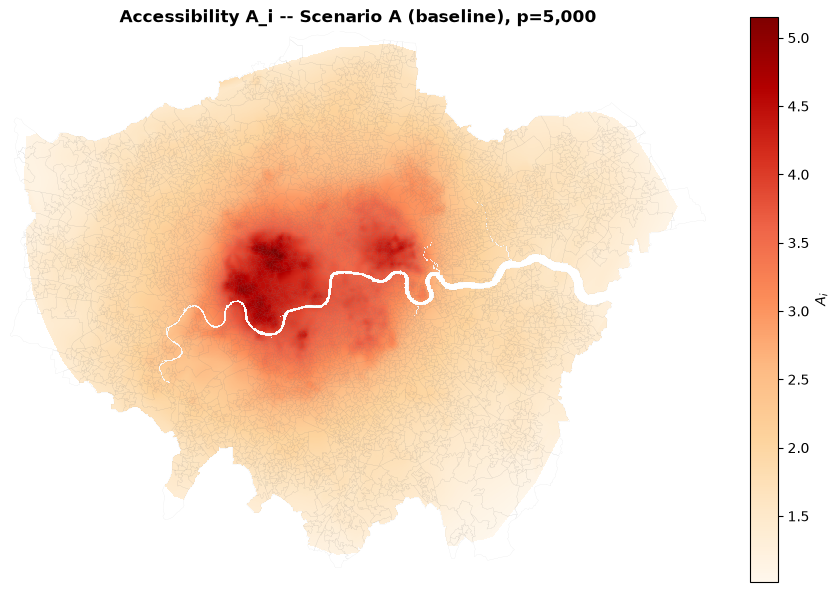

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/heatmap_delta_A_B_minus_A_p5000.png


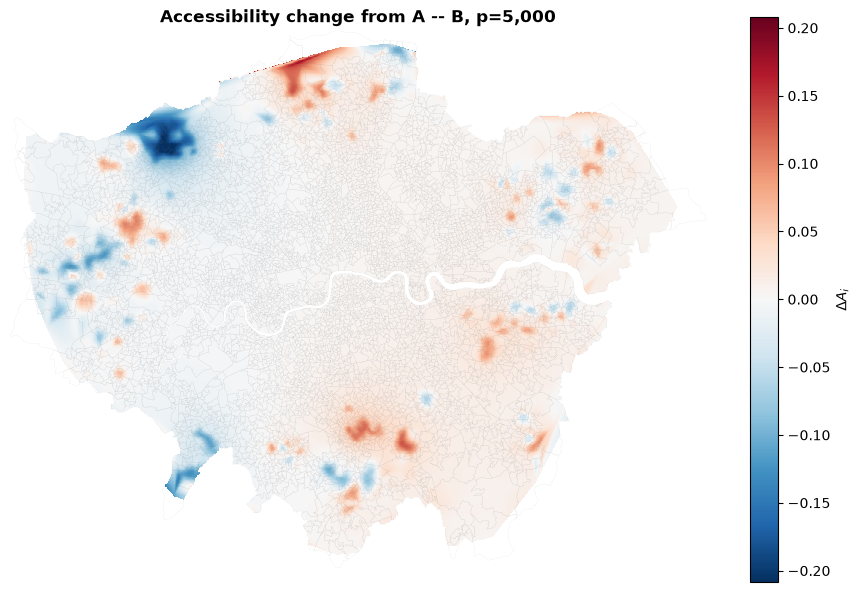

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/heatmap_delta_A_C_minus_A_p5000.png


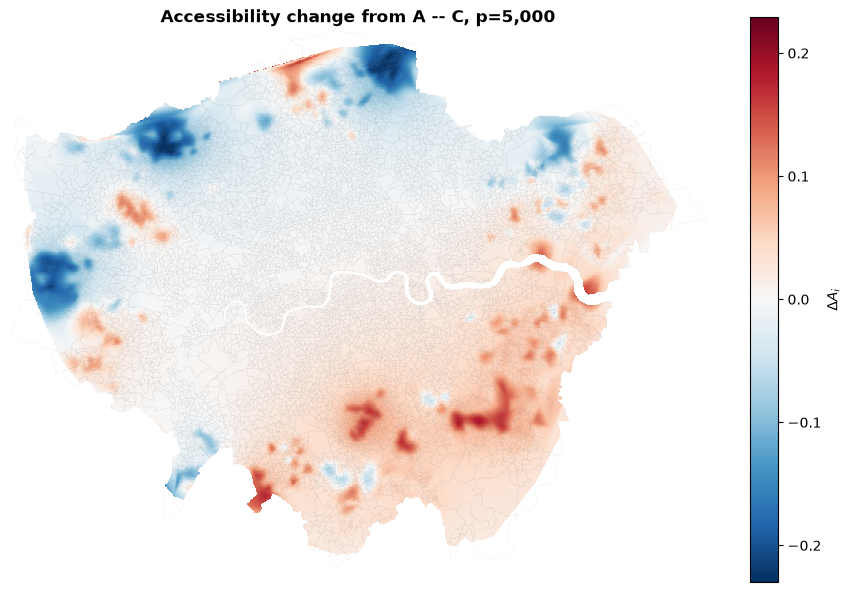

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/heatmap_delta_A_D_minus_A_p5000.png


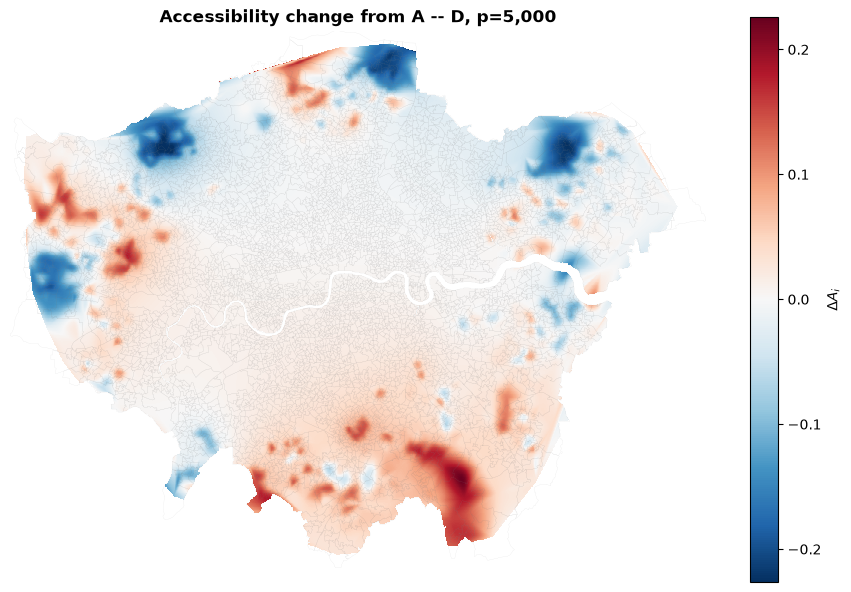

In [28]:
if core_results and all((scenario, P_REF) in core_results for scenario in SCENARIOS):
    fig, ax = plt.subplots(figsize=(9, 9))
    plot_smooth_heatmap(
        compute_accessibility(core_results[("A", P_REF)]["x_j"]), ax,
        f"Accessibility A_i -- Scenario A (baseline), p={P_REF:,}",
        cmap="OrRd", legend_label=r"$A_i$",
    )
    save_current_figure(f"heatmap_A_i_A_p{P_REF}.png")

    baseline_A_i = compute_accessibility(core_results[("A", P_REF)]["x_j"])
    for scenario_label in ["B", "C", "D"]:
        delta = compute_accessibility(core_results[(scenario_label, P_REF)]["x_j"]) - baseline_A_i
        fig, ax = plt.subplots(figsize=(9, 9))
        plot_smooth_heatmap(
            delta, ax, f"Accessibility change from A -- {scenario_label}, p={P_REF:,}",
            cmap="RdBu_r", diverging=True, legend_label=r"$\Delta A_i$",
        )
        save_current_figure(f"heatmap_delta_A_{scenario_label}_minus_A_p{P_REF}.png")
else:
    print("Heatmaps skipped: all four reference-p scenarios are required.")


/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_12322/1652891029.py:34: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_A_i_A_p5000.png


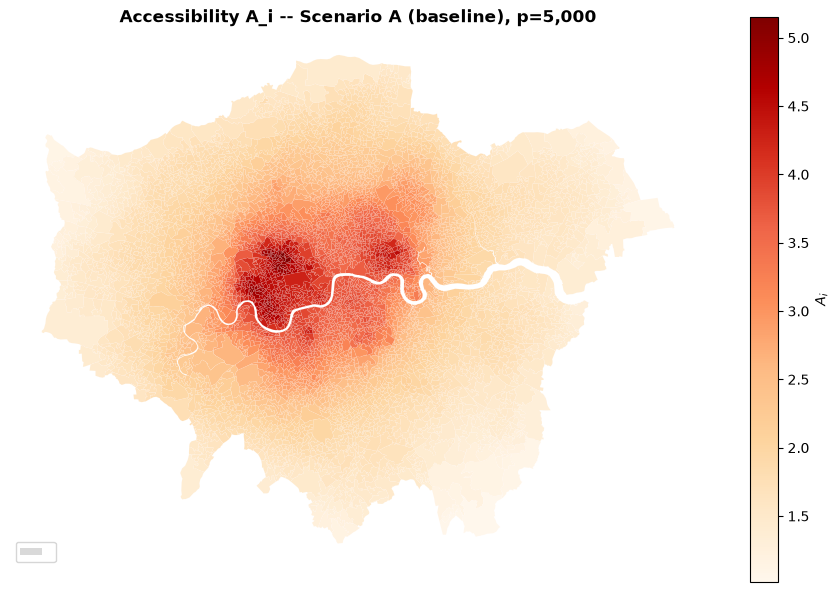

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_12322/1652891029.py:34: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_A_B_minus_A_p5000.png


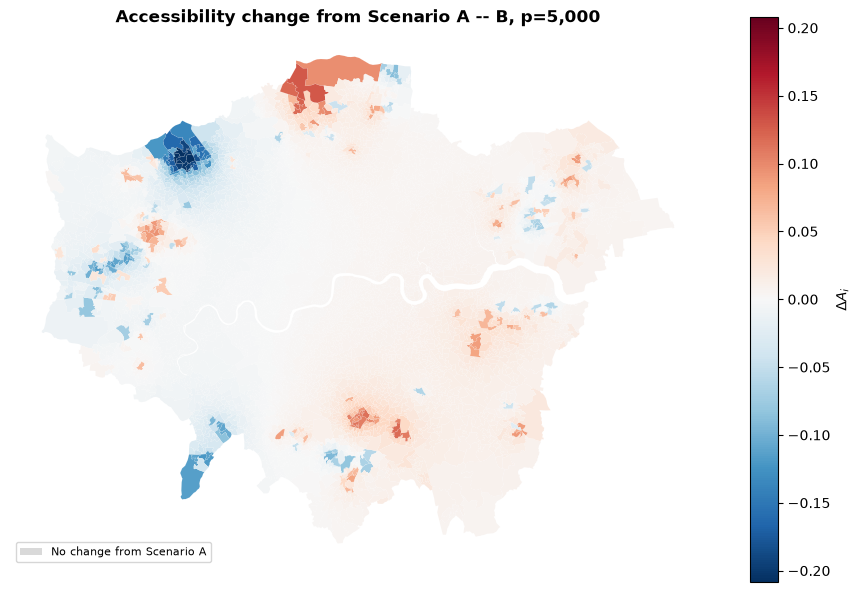

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_12322/1652891029.py:34: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_A_C_minus_A_p5000.png


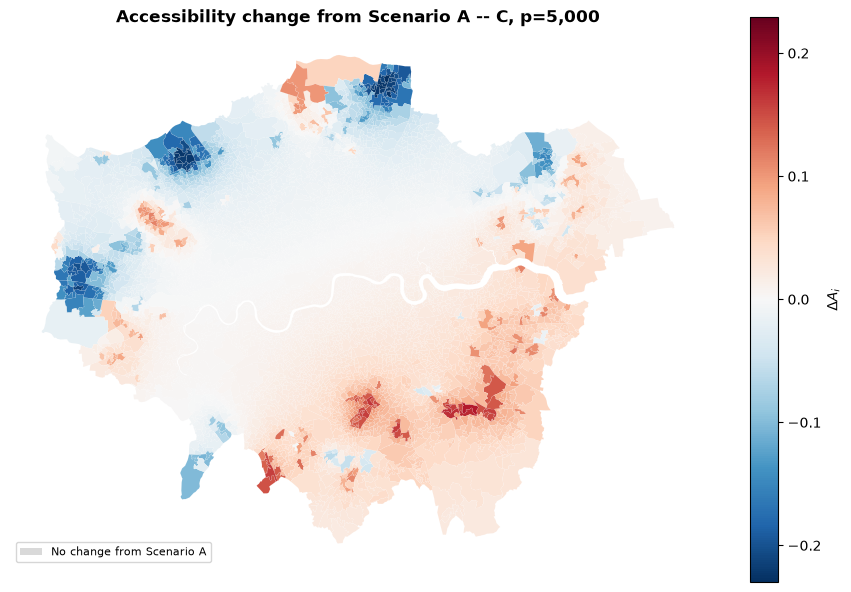

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_12322/1652891029.py:34: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  unchanged.plot(ax=ax, color=zero_color, edgecolor="white", linewidth=0.05)


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_A_D_minus_A_p5000.png


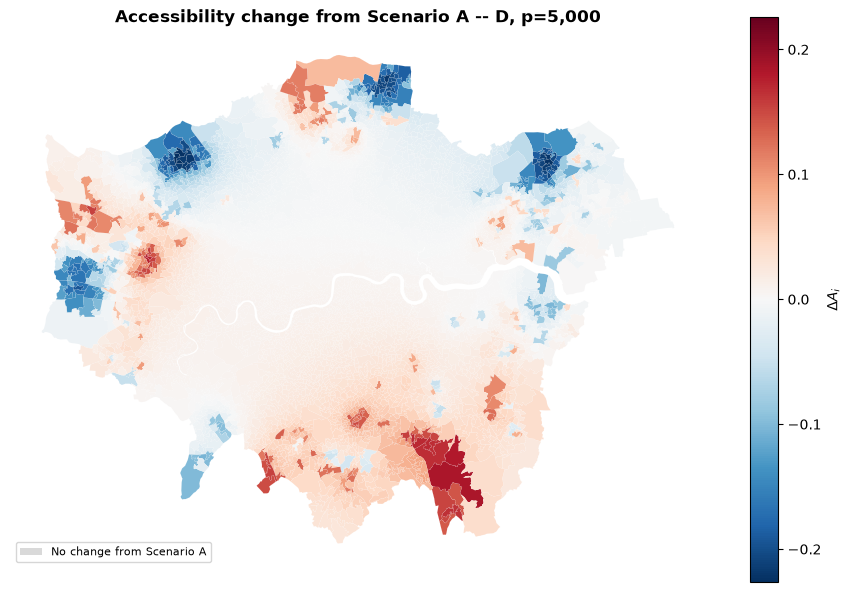

In [30]:
# A_i baseline（连续色阶，非diverging，因为A_i本身不会是负数）
plot_data = map_base.copy()
plot_data["A_i"] = compute_accessibility(core_results[("A", P_REF)]["x_j"])
fig, ax = plt.subplots(figsize=(9, 9))
plot_split_choropleth(
    plot_data, "A_i", ax, f"Accessibility A_i -- Scenario A (baseline), p={P_REF:,}",
    cmap="OrRd", legend_label=r"$A_i$", zero_tolerance=-1,  # 传-1相当于关掉"零值判断"，A_i恒为正
    zero_label="",
)
save_current_figure(f"map_A_i_A_p{P_REF}.png")

# delta_A_i（发散色阶，跟delta_x同一套逻辑）
baseline_A_i = compute_accessibility(core_results[("A", P_REF)]["x_j"])
for scenario_label in ["B", "C", "D"]:
    plot_data = map_base.copy()
    plot_data["delta_A_i"] = compute_accessibility(core_results[(scenario_label, P_REF)]["x_j"]) - baseline_A_i
    fig, ax = plt.subplots(figsize=(9, 9))
    plot_split_choropleth(
        plot_data, "delta_A_i", ax, f"Accessibility change from Scenario A -- {scenario_label}, p={P_REF:,}",
        cmap="RdBu_r", diverging=True, legend_label=r"$\Delta A_i$",
        zero_label="No change from Scenario A",
    )
    save_current_figure(f"map_delta_A_{scenario_label}_minus_A_p{P_REF}.png")

## 9.6 Assignment weight vs distance ($y_{ij}$ vs $d_{ij}$)

Requires `SAVE_POSITIVE_ASSIGNMENTS=True` (set in section 0) for the reference investment level
$p=5{,}000$ -- with no smoke-test subset any more, every core configuration saves its
assignment rows uniformly, so all four scenarios have data here (previously only $p=8{,}000$
did, because the smoke-test-reused configurations at $p=2{,}000/5{,}000$ were solved without
`save_assignments=True`).

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_yij_dij_scatter_p5000.png


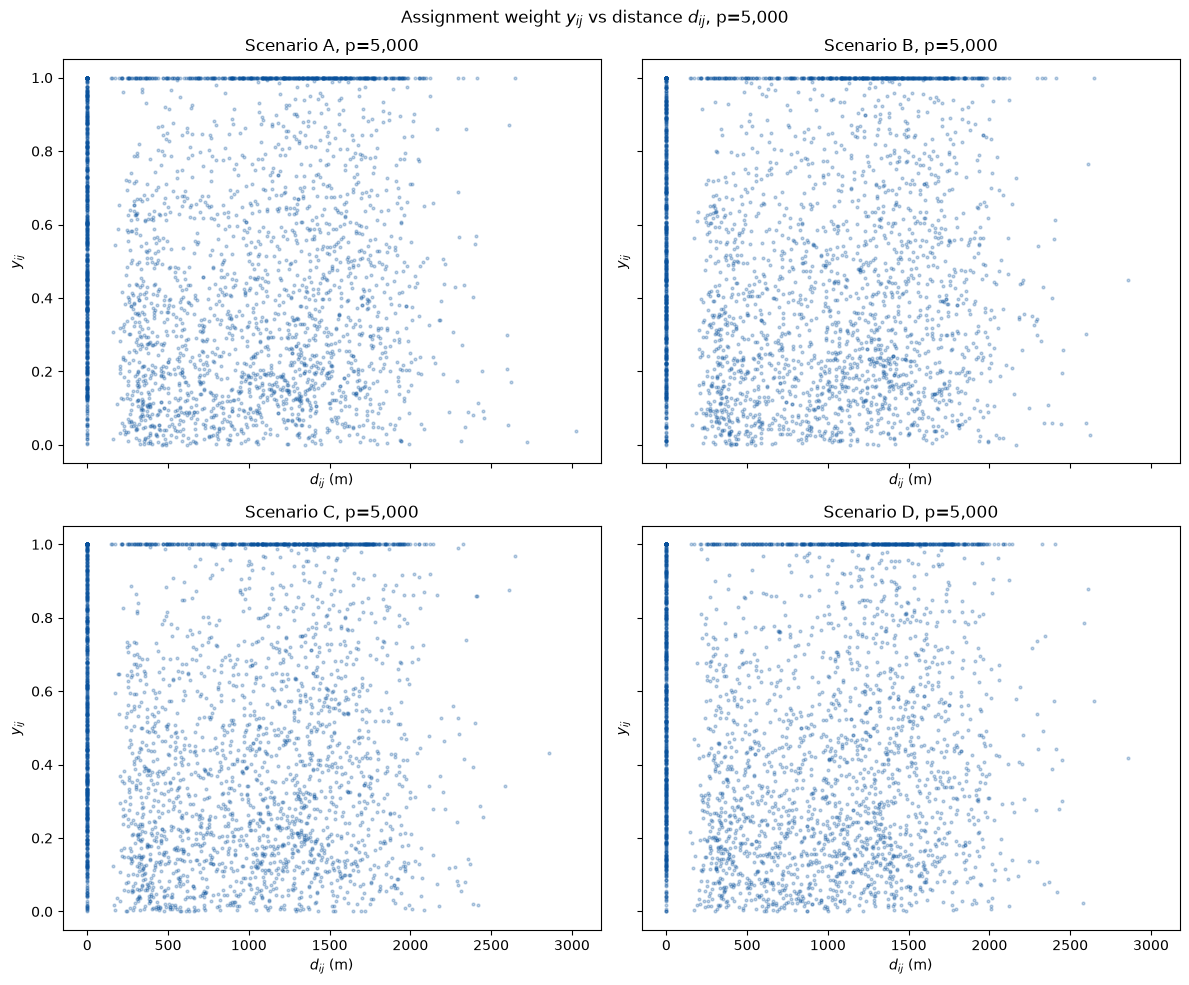

In [16]:
def plot_assignment_distance_scatter(scenario_label: str, p: int, ax, sample_size: int = 20_000) -> None:
    result = core_results.get((scenario_label, p))
    if result is None or result["assignment_rows"].empty:
        ax.set_title(f"Scenario {scenario_label}, p={p:,} (no saved assignment rows)")
        ax.axis("off")
        return
    rows = result["assignment_rows"]
    if len(rows) > sample_size:
        rows = rows.sample(sample_size, random_state=42)
    ax.scatter(rows["distance_m"], rows["y_ij"], s=4, alpha=0.25, color="#08519c")
    ax.set_xlabel(r"$d_{ij}$ (m)")
    ax.set_ylabel(r"$y_{ij}$")
    ax.set_title(f"Scenario {scenario_label}, p={p:,}")


if core_results and all((scenario, P_REF) in core_results for scenario in SCENARIOS):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    for ax, scenario_label in zip(axes.flat, SCENARIOS):
        plot_assignment_distance_scatter(scenario_label, P_REF, ax)
    plt.suptitle(rf"Assignment weight $y_{{ij}}$ vs distance $d_{{ij}}$, p={P_REF:,}")
    plt.tight_layout()
    save_current_figure(f"fig_yij_dij_scatter_p{P_REF}.png")
else:
    print("Assignment-distance scatter skipped: all four reference-p scenarios are required.")


## 9.7 Scenario-change and top-allocation tables

In [17]:
if core_results:
    change_rows: list[dict] = []
    for p in P_VALUES:
        baseline_key = ("A", p)
        if baseline_key not in core_results:
            continue
        baseline_x = core_results[baseline_key]["x_j"]
        baseline_A_i = compute_accessibility(baseline_x)

        for scenario_label in ["B", "C", "D"]:
            key = (scenario_label, p)
            if key not in core_results:
                continue
            x_values = core_results[key]["x_j"]
            A_i = compute_accessibility(x_values)
            correlation = spearmanr(baseline_x, x_values).statistic
            change_rows.append({
                "scenario": scenario_label, "alpha": SCENARIOS[scenario_label]["alpha"], "p": p,
                "L1_change_in_x_j": float(np.abs(x_values - baseline_x).sum()),
                "n_lsoas_gaining_capacity": int((x_values > baseline_x).sum()),
                "n_lsoas_losing_capacity": int((x_values < baseline_x).sum()),
                "spearman_x_vs_baseline": float(correlation),
                "total_absolute_change_in_A_i": float(np.abs(A_i - baseline_A_i).sum()),
            })

    scenario_change_summary = pd.DataFrame(change_rows)
    scenario_change_summary.to_csv(TABLES_DIR / "scenario_change_from_baseline.csv", index=False)
    print("\n=== Change from Scenario A ===")
    print(scenario_change_summary.to_string(index=False))

    top_rows: list[pd.DataFrame] = []
    for scenario_label in SCENARIOS:
        key = (scenario_label, P_REF)
        if key not in core_results:
            continue
        table = lsoa_master[["lsoa_code", "e_i", "D_A", "IMD_i", "london_income_decile"]].copy()
        table["scenario"] = scenario_label
        table["alpha"] = SCENARIOS[scenario_label]["alpha"]
        table["p"] = P_REF
        table["x_j"] = core_results[key]["x_j"]
        table["A_i"] = compute_accessibility(core_results[key]["x_j"])
        top_rows.append(table.nlargest(20, "x_j"))

    if top_rows:
        top_allocations = pd.concat(top_rows, ignore_index=True)
        top_allocations.to_csv(TABLES_DIR / "top_20_allocations_by_scenario.csv", index=False)
        print("\n=== Top 20 allocations by reference-p scenario ===")
        print(top_allocations.to_string(index=False))
else:
    scenario_change_summary = pd.DataFrame()
    top_allocations = pd.DataFrame()
    print("Scenario-change tables skipped: run the full grid first.")



=== Change from Scenario A ===
scenario  alpha    p  L1_change_in_x_j  n_lsoas_gaining_capacity  n_lsoas_losing_capacity  spearman_x_vs_baseline  total_absolute_change_in_A_i
       B    0.1 2000             762.0                        74                       59                0.794302                     25.011276
       C    0.3 2000             822.0                       145                       60                0.798767                     25.496723
       D    0.5 2000            1480.0                       192                      105                0.635624                     61.243106
       B    0.1 5000            1468.0                       206                      116                0.835616                     61.863110
       C    0.3 5000            2476.0                       417                      194                0.733655                    138.180716
       D    0.5 5000            3044.0                       527                      235               

## 9.8 Extended investment-sensitivity figures (optional)

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_extended_p_A_bar.png


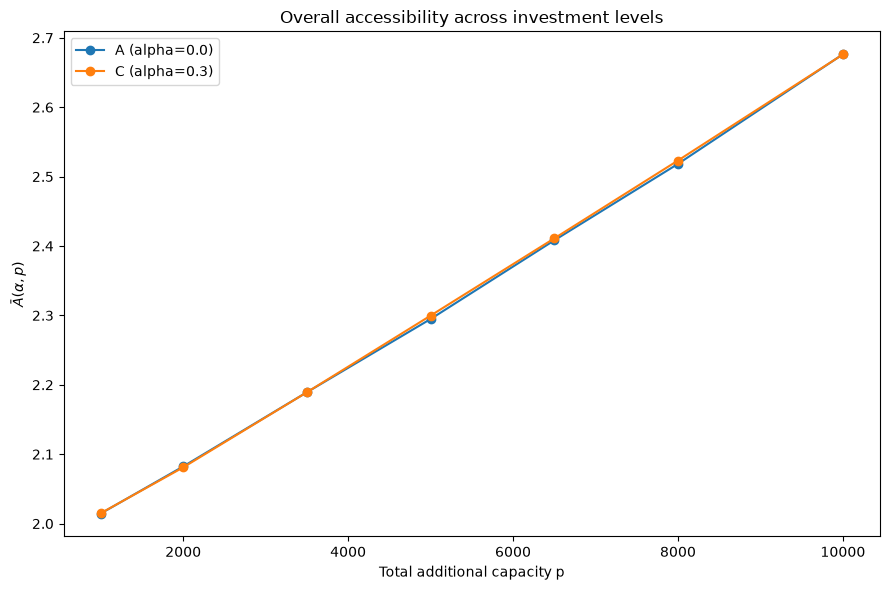

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_extended_p_slack.png


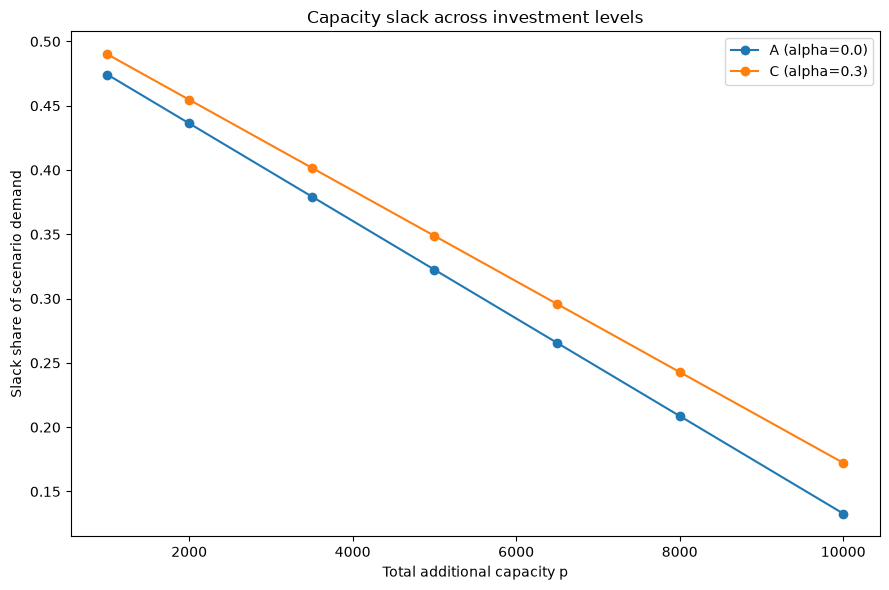

In [21]:
if not extended_p_summary.empty:
    for metric, ylabel, title, filename in [
        ("A_bar", r"$\bar A(\alpha,p)$", "Overall accessibility across investment levels",
         "fig_extended_p_A_bar.png"),
        ("slack_share_of_demand", "Slack share of scenario demand",
         "Capacity slack across investment levels", "fig_extended_p_slack.png"),
    ]:
        plt.figure(figsize=(9, 6))
        for scenario_label in EXTENDED_P_SCENARIOS:
            subset = extended_p_summary.loc[extended_p_summary["scenario"].eq(scenario_label)].sort_values("p")
            plt.plot(subset["p"], subset[metric], marker="o",
                      label=f"{scenario_label} (alpha={SCENARIOS[scenario_label]['alpha']})")
        plt.xlabel("Total additional capacity p")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        save_current_figure(filename)
else:
    print("Extended-p figures skipped: enable RUN_EXTENDED_P_SENSITIVITY.")


## 10. Interpretation and reporting rules

1. Report the CBC solver status, runtime, and reported optimality gap for every $(\alpha,p)$
   configuration. `Optimal` certifies optimality only for the sparse MILP actually formulated
   using the selected $k$, $K$, $U_j$ -- there is no service-radius setting to qualify further
   (C5 removed).
2. $\lambda \sum_j s_j$ is a feasibility penalty, not a substantive result. Report
   `distance_objective` separately from `penalised_objective`; only the former, together with
   $A_i(\alpha,p)$, answers the research questions.
3. $A_i(\alpha,p)$, $\bar A(\alpha,p)$ and $\Delta A_i(\alpha,p)$ are the primary Phase 4
   outputs, computed on the full Greater London network, independent of the solver's $k$-NN
   sparsification.
4. $\bar A(\alpha,p)$ can be near-flat across $\alpha$ even when $x_j$ responds strongly and
   monotonically -- the aggregate mean can mask real spatial reallocation. The
   deprivation-decile profile of $\Delta A_i(\alpha,p)$, not $\bar A$ alone, is the primary
   evidence for whether the equity weighting has the intended distributional effect.
5. `slack_share_of_demand` is reported as a feasibility diagnostic alongside $\bar A(\alpha,p)$
   -- it answers a distinct question (how much recognised demand the capacity constraints could
   not accommodate) that the accessibility measure does not capture on its own.
6. A high own-LSOA assignment share is not automatically an error; interpret it together with
   `slack_share_of_demand` and the number of LSOAs receiving $x_j>0$.
7. Decile profiles, allocation/accessibility-change maps and the core $\bar A(\alpha,p)$/
   $\Delta A_i(\alpha,p)$ results are the primary Results-chapter material. $K$/$U_j$/$k$
   sensitivity and the extended investment curve are Discussion/appendix material.


In [22]:
# 临时对照：把四个情景的demand重新normalize到跟baseline总量一致，
# 只用来测试decile pattern会不会变，不替换正式的demand_london.csv
def normalized_demand_col(df, alpha_col, baseline_col="D_A"):
    total_baseline = df[baseline_col].sum()
    total_alpha = df[alpha_col].sum()
    return df[alpha_col] * (total_baseline / total_alpha)

demand_normalized_check = lsoa_master[["lsoa_code", "D_A", "D_B", "D_C", "D_D"]].copy()
for col in ["D_B", "D_C", "D_D"]:
    demand_normalized_check[f"{col}_norm"] = normalized_demand_col(demand_normalized_check, col)

# 用normalize后的列重新跑一次p=5000的四个情景（复用现有K0、candidate set，不用重建）
SCENARIOS_NORM = {
    "A": {"alpha": 0.0, "demand_col": "D_A"},
    "B": {"alpha": 0.1, "demand_col": "D_B_norm"},
    "C": {"alpha": 0.3, "demand_col": "D_C_norm"},
    "D": {"alpha": 0.5, "demand_col": "D_D_norm"},
}
lsoa_master_norm = lsoa_master.copy()
for col in ["D_B_norm", "D_C_norm", "D_D_norm"]:
    lsoa_master_norm[col] = demand_normalized_check[col]

norm_results = {}
for label, spec in SCENARIOS_NORM.items():
    lsoa_master_backup, SCENARIOS_backup = lsoa_master, SCENARIOS
    lsoa_master, SCENARIOS = lsoa_master_norm, {label: spec}  # 临时替换全局引用
    norm_results[label] = solve_capacity_allocation(
        scenario_label=label, p=5_000, K=K0, U_j=U_MAX, k=K_NEIGHBOURS,
        time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS, save_assignments=False,
    )
    lsoa_master, SCENARIOS = lsoa_master_backup, SCENARIOS_backup  # 恢复

baseline_A_i_norm = compute_accessibility(norm_results["A"]["x_j"])
deciles = lsoa_master["london_income_decile"].to_numpy(dtype=int)
for label in ["B", "C", "D"]:
    delta = compute_accessibility(norm_results[label]["x_j"]) - baseline_A_i_norm
    d1 = weighted_mean(delta[deciles == 1], D0[deciles == 1])
    d10 = weighted_mean(delta[deciles == 10], D0[deciles == 10])
    print(f"{label}: decile1 delta_A={d1:.4f}, decile10 delta_A={d10:.4f}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/coin_api.py:212: UserWarning: `logPath` argument replaces `msg=1`. The output will be redirected to the log file.
  warnings.warn(


B: decile1 delta_A=-0.0119, decile10 delta_A=0.0063
C: decile1 delta_A=-0.0110, decile10 delta_A=0.0126
D: decile1 delta_A=-0.0092, decile10 delta_A=0.0120


In [29]:
# 找出图三里红得最深的那几个LSOA，看看它们的身份
delta_x_D = core_results[("D", P_REF)]["x_j"] - core_results[("A", P_REF)]["x_j"]
top_gainers = lsoa_master.assign(delta_x=delta_x_D).nlargest(10, "delta_x")
print(top_gainers[["lsoa_code", "delta_x", "D_A", "e_i", "london_income_decile"]])

# 顺便对比一下C情景下同一批LSOA的情况，看是不是C那时候还没涨上来
delta_x_C = core_results[("C", P_REF)]["x_j"] - core_results[("A", P_REF)]["x_j"]
print(pd.Series(delta_x_C, index=lsoa_master["lsoa_code"]).loc[top_gainers["lsoa_code"]])

      lsoa_code  delta_x         D_A  e_i  london_income_decile
636   E01000666     13.0  168.118831    0                    10
715   E01000747     13.0  164.098052    0                     8
1362  E01001417     11.0  144.371104    0                    10
1367  E01001422     11.0  144.245455    0                    10
2395  E01002512     11.0  142.360714    0                     8
2415  E01002537     11.0  146.884091    0                     9
3914  E01004114     11.0  147.135390    0                    10
1357  E01001412     10.0  117.607792    0                     5
3944  E01004145     10.0  128.162338    0                     8
4516  E01032570     10.0  139.296894    1                     8
lsoa_code
E01000666     0.0
E01000747     0.0
E01001417    11.0
E01001422    11.0
E01002512     0.0
E01002537     0.0
E01004114    11.0
E01001412     9.0
E01004145    10.0
E01032570     0.0
dtype: float64


In [31]:
# Robustness check: does the "desert-filling" pattern (new capacity concentrating in
# e_i=0 LSOAs that are disproportionately in less-deprived deciles) also hold at
# p=2,000 and p=8,000, not just the reference p=5,000?

for p_check in [2_000, 8_000]:
    delta_x_D = core_results[("D", p_check)]["x_j"] - core_results[("A", p_check)]["x_j"]
    top_gainers = lsoa_master.assign(delta_x=delta_x_D).nlargest(20, "delta_x")

    share_desert = (top_gainers["e_i"] == 0).mean()
    mean_decile = top_gainers["london_income_decile"].mean()
    share_least_deprived_half = (top_gainers["london_income_decile"] >= 6).mean()

    print(f"\n=== p={p_check:,}, Scenario D vs A, top 20 gainers by delta_x ===")
    print(top_gainers[["lsoa_code", "delta_x", "D_A", "e_i", "london_income_decile"]].to_string(index=False))
    print(f"\nShare of top-20 gainers with e_i=0 (true desert): {share_desert:.0%}")
    print(f"Mean london_income_decile among top-20 gainers: {mean_decile:.1f} (1=most deprived, 10=least)")
    print(f"Share of top-20 gainers in deciles 6-10 (less-deprived half): {share_least_deprived_half:.0%}")


=== p=2,000, Scenario D vs A, top 20 gainers by delta_x ===
lsoa_code  delta_x        D_A  e_i  london_income_decile
E01001417     11.0 144.371104    0                    10
E01001422     11.0 144.245455    0                    10
E01004114     11.0 147.135390    0                    10
E01001071     10.0 124.518506    0                     8
E01001412     10.0 117.607792    0                     5
E01003737     10.0 129.670130    0                     8
E01032623     10.0 137.586039    0                    10
E01000114      9.0 102.655519    0                     3
E01000720      9.0 104.037662    0                     2
E01000722      9.0 110.697078    0                     5
E01000759      9.0 124.644156    0                    10
E01001072      9.0 121.251623    0                    10
E01001402      9.0 112.833117    0                     7
E01002303      9.0 113.335714    0                     5
E01002336      9.0 113.461364    0                     8
E01002401      9.0 102.2785

三档全部一致：desert占比从没低于80%，落在"不太贫困"那一半的比例从没低于70%。 而且能看出一个额外的、值得写一句的细节：投资规模越大，这个"偏向富裕区"的倾向反而越明显（decile 6-10占比从70%涨到95%）——这个也说得通：
p
p越大，模型能腾出手来的"划算desert"选择就越多，越有条件把资源集中导向填坑效率最高的地方，这跟你K sensitivity那里"容量越松弛、模型行为越接近某种极限状态"的逻辑是一致的。
这条可以直接补进discussion，作为"该模式跨投资规模稳定存在，且强度随投资规模递增"这一句的证据。